<a href="https://colab.research.google.com/github/lpodina/conformal_pinns/blob/main/Alpha_interval_Conformal_PINNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import warnings
from scipy.integrate import odeint
from matplotlib import style
import numpy as np

warnings.filterwarnings('ignore')

np.random.seed(1234)

# CUDA support
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Device is {device}")
"""## Physics-informed Neural Networks"""

# define the right-hand side
def logistic_growth(N, t, r, K):
    return r * N * (1 - N/K)

Device is cuda


In [ ]:
def generate_data(noise, alpha, id):
  '''generates and returns data (logistic growth) using input parameters
     noise: amount of noise to add (>= 0)
     alpha: growth rate
     id: experiment id under which to save

     returns: dict {"t": numpy array with all time points,
                    "t_train": numpy array with training points (t),
                    "t_test": numpy array with test points (t),
                    "t_cal": numpy array with calibration points (t),

                    "N": numpy array with all points (N),
                    "N_train": numpy array with train points (N),
                    "N_test": numpy array with test points (N),
                    "N_cal": numpy array with calibration points (N),

                    "alpha": real value of current alpha,
                    "id": id of experiment,
                    "noise": noise of generated data}
  '''

  max_t = 150
  step_size = 1.0
  #step_size = 0.1 # MTR
  noise = noise # e.g. 0.0 or 0.03 <- change this to 0.03 to see how noise will affect performance

  t = np.arange(0, max_t, step_size) #0.1
  p_ = (alpha, 1.0)

  ic = 0.1
  # X is ideal noiseless data
  X = odeint(logistic_growth, ic, t, args=p_)

  # Add noise according to the mean
  xbar = np.mean(X, axis=0)
  Xn = X + noise * xbar * np.random.randn(*X.shape)

  t_cal, t_traintest, N_cal, N_traintest = train_test_split(t, Xn, test_size=0.33, random_state=42)
  t_train, t_test, N_train, N_test = train_test_split(t_traintest, N_traintest, test_size=0.50, random_state=42)

  print(f"num calibration: {t_cal.shape},{N_cal.shape}")
  print(f"num train: {t_train.shape},{N_train.shape}")
  print(f"num test: {t_test.shape},{N_test.shape}")

  t_train = np.expand_dims(t_train.copy(),axis=1)
  t_test = np.expand_dims(t_test.copy(),axis=1)
  t_cal = np.expand_dims(t_cal.copy(),axis=1)

  # plot the data for sanity check
  plt.grid()
  plt.title("Data points")
  plt.xlabel("Time")
  plt.ylabel("N")
  plt.plot(t, Xn,'o',label='all')
  plt.plot(t_train, N_train,'o',label='train')
  plt.legend()
  plt.savefig(f'data_{id}')
  plt.show()
  plt.clf()

  return {"id": id,
          "alpha": alpha,
          "noise": noise,

          "t": t,
          "t_train": t_train,
          "t_test": t_test,
          "t_cal": t_cal,

          "N": Xn,
          "N_train": N_train,
          "N_test": N_test,
          "N_cal": N_cal}

num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


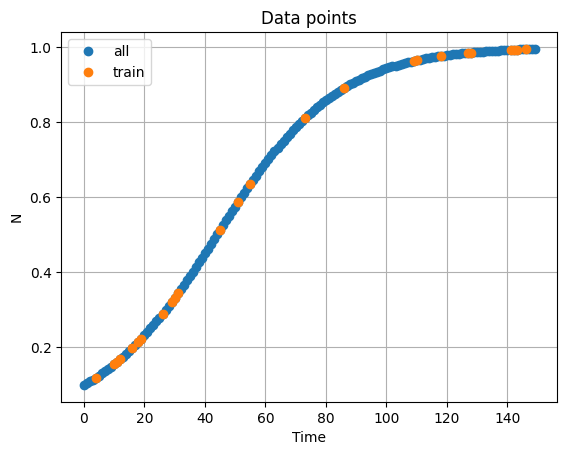

<Figure size 640x480 with 0 Axes>

In [ ]:
generate_data(0.0, 0.05, 0);

In [ ]:

# the deep neural network
class DNN(torch.nn.Module):
    def __init__(self, layers, min_val, max_val):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        self.min_val = torch.tensor([min_val], requires_grad=True).float().to(device)
        self.max_val = torch.tensor([max_val], requires_grad=True).float().to(device)

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        res = (x - self.min_val) / (self.max_val - self.min_val)
        out = self.layers(res)
        return out

max_lr = -1
min_lr = -3

time_delta = 30000
warm_ups = 1000
rate = (min_lr - max_lr) / time_delta

def lr_schedule(epoch):
    """Linear annealing LR schedule."""
    if epoch < warm_ups:
        return 10**(max_lr)
    elif epoch < time_delta:
        return 10**(rate * (epoch - warm_ups) + max_lr)
    else:
        return 10**min_lr

# the physics-guided neural network
class PhysicsInformedNN():
    def __init__(self, t_colloc, layers, t_train, u_data):

        # save the training data
        self.t_train = torch.tensor(t_train, requires_grad=True).float().to(device) # t
        self.u_data = torch.tensor(u_data, requires_grad=True).float().to(device) # N

        # save the collocation times as well
        self.t_colloc = torch.tensor(t_colloc, requires_grad=True).float().to(device)

        # You need to know the parameters of the differential equation
        self.r = torch.tensor([0.01], requires_grad=True).float().to(device) # parameters
        self.K = torch.tensor([1.0], requires_grad=True).float().to(device)

        # deep neural networks
        print(f"layers: {layers}")

        self.dnn = DNN(layers,0.0,150.0).to(device)

        # optional 4 lines: if you want to fit the parameters as well
        self.r = torch.nn.Parameter(self.r)
        # self.K = torch.nn.Parameter(self.K) # assume K to be known
        self.dnn.register_parameter('r', self.r)
        # self.dnn.register_parameter('K', self.K)

         # optimizers: using the same settings
        self.optimizer = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=50000,
            max_eval=50000,
            history_size=50,
            tolerance_grad=0,#1e-8,
            tolerance_change=0,#1.0 * np.finfo(float).eps,
            line_search_fn="strong_wolfe"       # can be "strong_wolfe"
        )

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters())
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(self.optimizer_Adam, lr_lambda=lr_schedule)
        self.iter = 0

    def net_u(self, t):
        u = self.dnn(t)
        return u

    def net_f(self, t_colloc):
        """ The pytorch autograd version of calculating residual """
        u_colloc = self.net_u(t_colloc)

        _u = torch.unsqueeze(u_colloc[:, 0],axis=1)

        u_t = torch.autograd.grad(
            _u, t_colloc,
            grad_outputs=torch.ones_like(_u),
            retain_graph=True,
            create_graph=True,
        )[0]

        u_dot = self.r * _u * (1 - _u/self.K)
        loss_pinn = torch.mean(torch.square(u_t - u_dot))

        return loss_pinn

    # this loss func is for the LBFGS optimizer
    def loss_func(self):
        self.optimizer.zero_grad()

        # compute the loss
        u_pred = self.net_u(self.t_train)
        data_loss = torch.mean((self.u_data - u_pred) ** 2) # mse loss
        pinn_loss = self.net_f(self.t_colloc) # pinn loss

        loss = data_loss + pinn_loss # add them together to get final loss

        loss.backward()

        self.iter += 1
        if self.iter % 100 == 0:
            print(
                'Loss: %.3e, pinn loss: %.3e, data loss: %.3e, r: %.3f, K: %.6f' %
                (
                    loss.item(),
                    pinn_loss.item(),
                    data_loss.item(),
                    self.r.item(),
                    self.K.item()
                )
            )
        return loss

    def train(self, adam_epochs, bfgs_epochs, polish_adam_epochs):
        self.dnn.train()

        for epoch in range(adam_epochs):
            u_pred = self.net_u(self.t_train)
            data_loss = torch.mean((self.u_data - u_pred) ** 2)
            pinn_loss = self.net_f(self.t_colloc)

            loss = data_loss + pinn_loss

            # Backward and optimize
            self.optimizer_Adam.zero_grad()
            loss.backward()
            self.optimizer_Adam.step()
            self.scheduler.step()

            if epoch % 100 == 0:
                print(
                    'It: %d, Loss: %.3e, pinn loss: %.3e, data loss: %.3e, r: %.3f, K: %.6f' %
                    (
                        epoch,
                        loss.item(),
                        pinn_loss.item(),
                        data_loss.item(),
                        self.r.item(),
                        self.K.item()
                    )
                )
        self.optimizer.step(self.loss_func)

    def predict(self, t):
        t = torch.tensor(t, requires_grad=True).float().to(device)

        self.dnn.eval()
        u = self.net_u(t)
        u = u.detach().cpu().numpy()
        return u

Step 2. Set Up Training
true alphas:  [0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115
 0.12  0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175
 0.18  0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235
 0.24  0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295
 0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415
 0.42  0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475
 0.48  0.485 0.49  0.495]


  0%|          | 0/100 [00:00<?, ?it/s]

num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


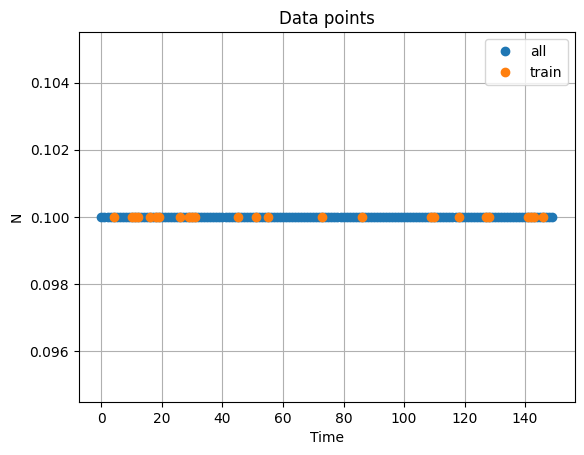

layers: [1, 10, 10, 1]
It: 0, Loss: 6.340e-03, pinn loss: 4.468e-06, data loss: 6.336e-03, r: 0.010, K: 1.000000
Loss: 1.004e-10, pinn loss: 1.565e-12, data loss: 9.882e-11, r: -0.000, K: 1.000000
Loss: 7.015e-11, pinn loss: 1.271e-12, data loss: 6.888e-11, r: -0.000, K: 1.000000
Loss: 6.886e-11, pinn loss: 1.139e-12, data loss: 6.773e-11, r: -0.000, K: 1.000000


  1%|          | 1/100 [00:03<06:28,  3.93s/it]

estimated alpha:  -1.8233314449389582e-06
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


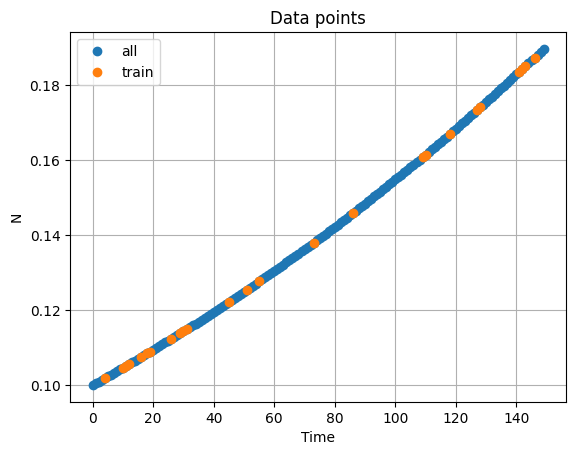

layers: [1, 10, 10, 1]
It: 0, Loss: 3.502e-01, pinn loss: 3.178e-05, data loss: 3.501e-01, r: 0.010, K: 1.000000


  2%|▏         | 2/100 [00:05<04:14,  2.60s/it]

estimated alpha:  0.0049790930934250355
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


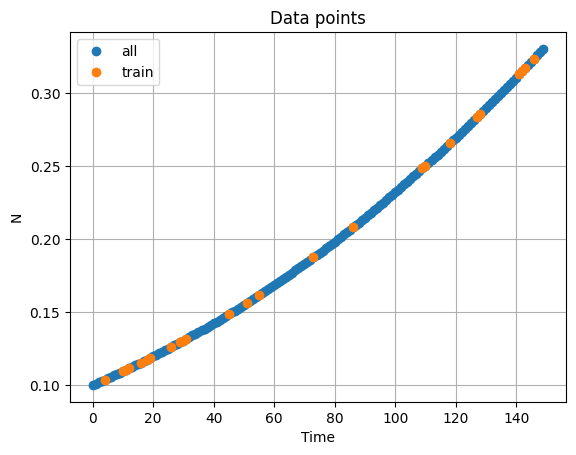

layers: [1, 10, 10, 1]
It: 0, Loss: 1.231e-02, pinn loss: 1.824e-06, data loss: 1.231e-02, r: 0.010, K: 1.000000
Loss: 1.089e-09, pinn loss: 2.165e-11, data loss: 1.067e-09, r: 0.010, K: 1.000000


  3%|▎         | 3/100 [00:07<04:00,  2.48s/it]

estimated alpha:  0.009997635148465633
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


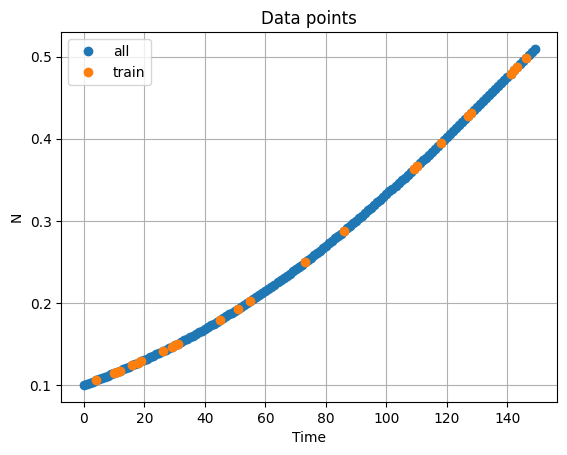

layers: [1, 10, 10, 1]
It: 0, Loss: 8.241e-02, pinn loss: 8.915e-08, data loss: 8.241e-02, r: 0.010, K: 1.000000


  4%|▍         | 4/100 [00:09<03:18,  2.07s/it]

estimated alpha:  0.015009589493274689
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


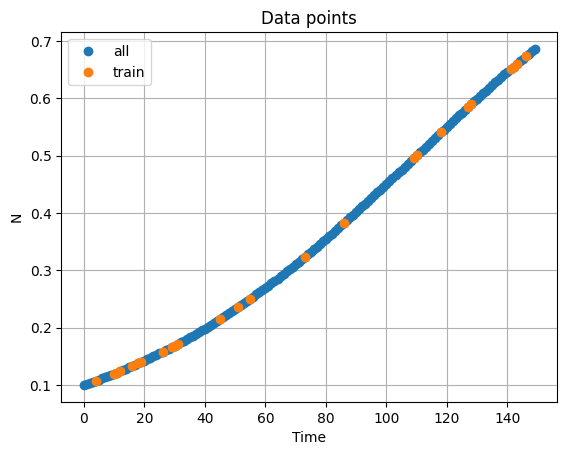

layers: [1, 10, 10, 1]
It: 0, Loss: 2.862e-01, pinn loss: 1.479e-06, data loss: 2.862e-01, r: 0.010, K: 1.000000


  5%|▌         | 5/100 [00:11<03:09,  2.00s/it]

estimated alpha:  0.020021015778183937
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


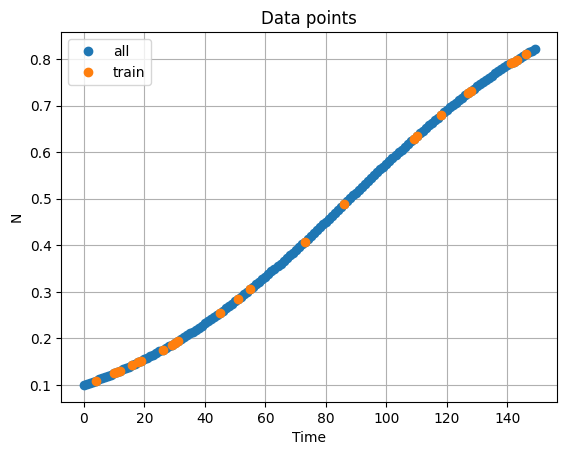

layers: [1, 10, 10, 1]
It: 0, Loss: 1.187e+00, pinn loss: 1.213e-04, data loss: 1.187e+00, r: 0.010, K: 1.000000


  6%|▌         | 6/100 [00:12<02:53,  1.84s/it]

estimated alpha:  0.025010449811816216
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


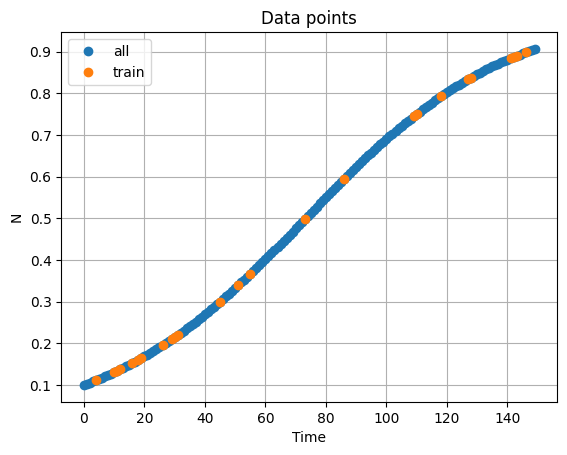

layers: [1, 10, 10, 1]
It: 0, Loss: 8.237e-01, pinn loss: 2.414e-05, data loss: 8.237e-01, r: 0.010, K: 1.000000


  7%|▋         | 7/100 [00:14<02:41,  1.74s/it]

estimated alpha:  0.03002334199845791
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


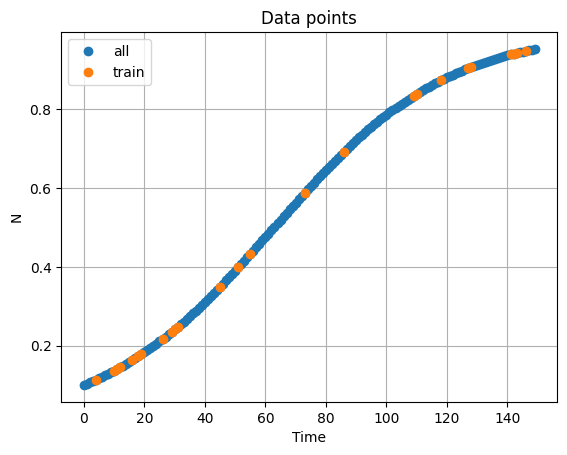

layers: [1, 10, 10, 1]
It: 0, Loss: 2.421e-01, pinn loss: 6.187e-07, data loss: 2.421e-01, r: 0.010, K: 1.000000
Loss: 9.594e-08, pinn loss: 1.055e-09, data loss: 9.488e-08, r: 0.035, K: 1.000000


  8%|▊         | 8/100 [00:17<03:11,  2.08s/it]

estimated alpha:  0.03500013053417206
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


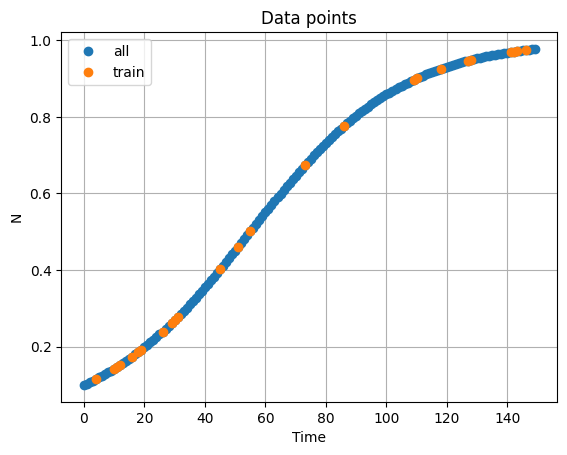

layers: [1, 10, 10, 1]
It: 0, Loss: 2.140e-01, pinn loss: 5.924e-06, data loss: 2.140e-01, r: 0.010, K: 1.000000
Loss: 1.689e-08, pinn loss: 7.033e-10, data loss: 1.619e-08, r: 0.040, K: 1.000000


  9%|▉         | 9/100 [00:19<03:20,  2.20s/it]

estimated alpha:  0.04000472649931908
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


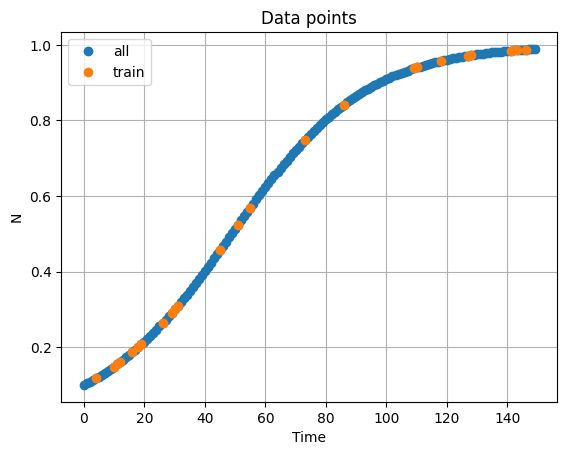

layers: [1, 10, 10, 1]
It: 0, Loss: 9.001e-01, pinn loss: 2.478e-05, data loss: 9.000e-01, r: 0.010, K: 1.000000


 10%|█         | 10/100 [00:21<03:08,  2.09s/it]

estimated alpha:  0.045083872973918915
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


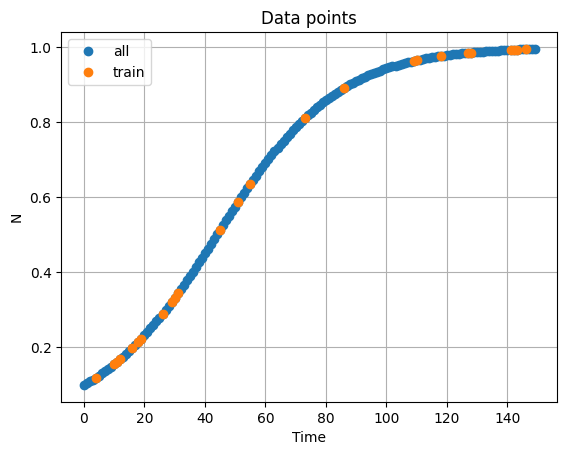

layers: [1, 10, 10, 1]
It: 0, Loss: 1.270e-01, pinn loss: 5.830e-06, data loss: 1.270e-01, r: 0.010, K: 1.000000
Loss: 6.285e-07, pinn loss: 1.894e-08, data loss: 6.096e-07, r: 0.050, K: 1.000000


 11%|█         | 11/100 [00:23<03:14,  2.18s/it]

estimated alpha:  0.0500260591506958
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


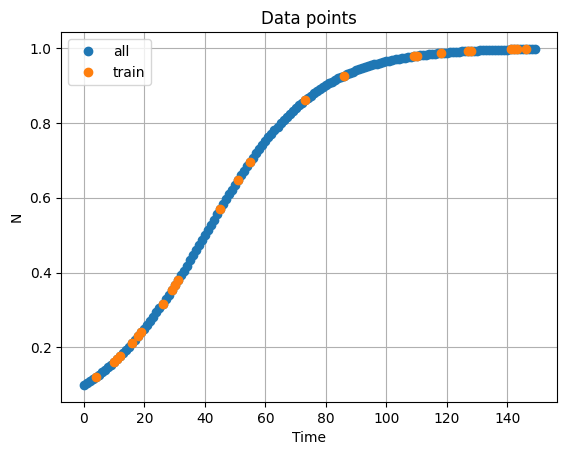

layers: [1, 10, 10, 1]
It: 0, Loss: 5.119e-01, pinn loss: 5.269e-07, data loss: 5.119e-01, r: 0.010, K: 1.000000


 12%|█▏        | 12/100 [00:25<03:03,  2.08s/it]

Loss: 2.055e-07, pinn loss: 1.206e-08, data loss: 1.935e-07, r: 0.055, K: 1.000000
estimated alpha:  0.055137839168310165
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


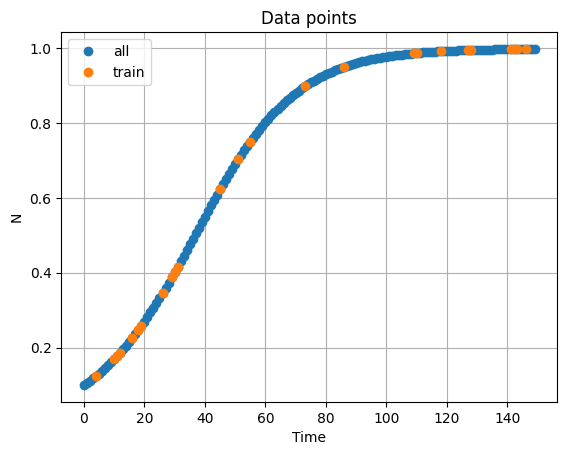

layers: [1, 10, 10, 1]
It: 0, Loss: 5.680e-01, pinn loss: 2.769e-06, data loss: 5.680e-01, r: 0.010, K: 1.000000


 13%|█▎        | 13/100 [00:27<02:49,  1.95s/it]

estimated alpha:  0.06000564992427826
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


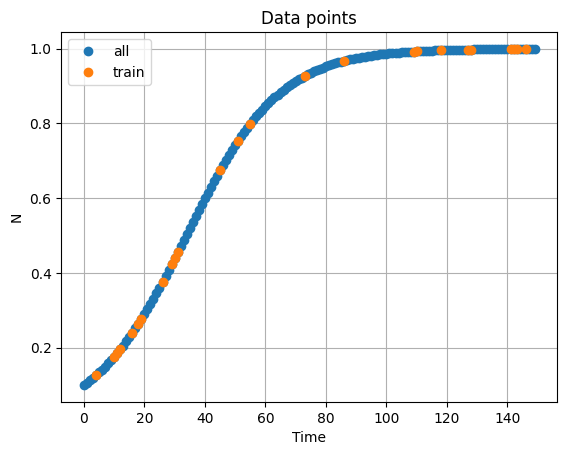

layers: [1, 10, 10, 1]
It: 0, Loss: 4.491e-01, pinn loss: 9.841e-07, data loss: 4.491e-01, r: 0.010, K: 1.000000


 14%|█▍        | 14/100 [00:29<02:56,  2.05s/it]

Loss: 1.910e-06, pinn loss: 6.827e-08, data loss: 1.842e-06, r: 0.065, K: 1.000000
estimated alpha:  0.06473354250192642
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


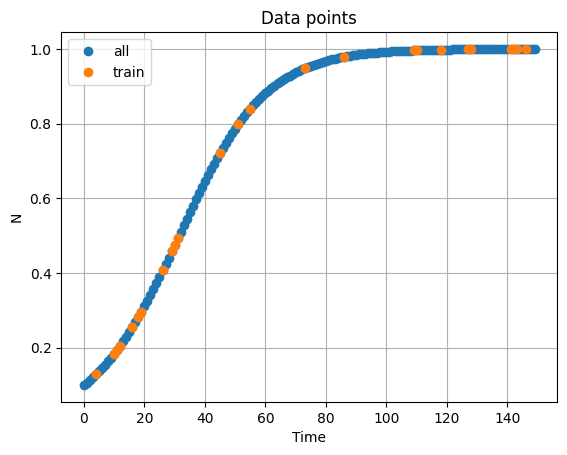

layers: [1, 10, 10, 1]
It: 0, Loss: 7.119e-01, pinn loss: 3.122e-06, data loss: 7.119e-01, r: 0.010, K: 1.000000


 15%|█▌        | 15/100 [00:31<02:58,  2.10s/it]

Loss: 1.553e-07, pinn loss: 5.656e-09, data loss: 1.496e-07, r: 0.070, K: 1.000000
estimated alpha:  0.06994007527828217
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


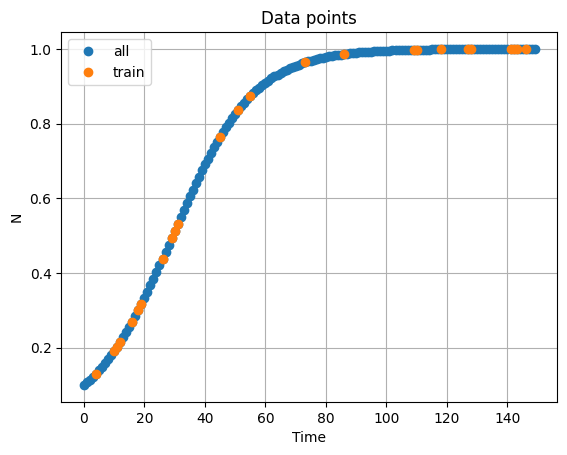

layers: [1, 10, 10, 1]
It: 0, Loss: 4.170e-01, pinn loss: 4.722e-06, data loss: 4.170e-01, r: 0.010, K: 1.000000
Loss: 1.885e-06, pinn loss: 5.916e-08, data loss: 1.826e-06, r: 0.074, K: 1.000000


 16%|█▌        | 16/100 [00:34<03:05,  2.21s/it]

estimated alpha:  0.07498667389154434
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


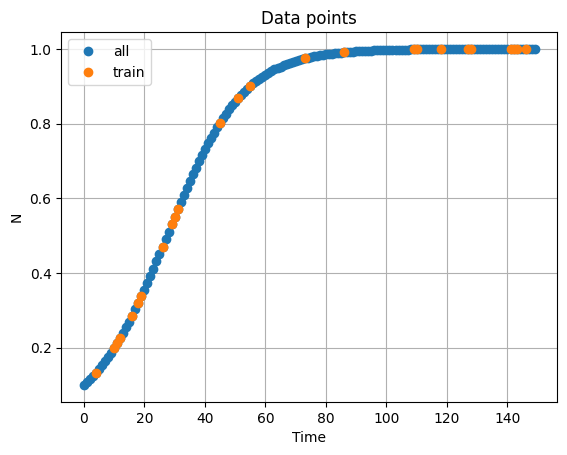

layers: [1, 10, 10, 1]
It: 0, Loss: 1.418e+00, pinn loss: 3.572e-05, data loss: 1.418e+00, r: 0.010, K: 1.000000


 17%|█▋        | 17/100 [00:36<03:00,  2.18s/it]

Loss: 1.742e-07, pinn loss: 1.202e-08, data loss: 1.622e-07, r: 0.080, K: 1.000000
estimated alpha:  0.08006566762924194
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


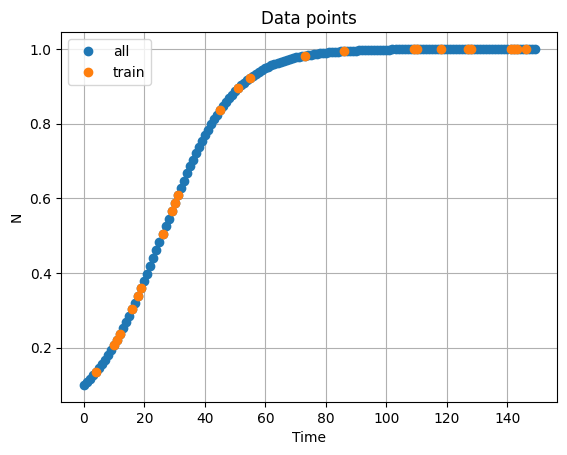

layers: [1, 10, 10, 1]
It: 0, Loss: 2.078e-01, pinn loss: 2.887e-06, data loss: 2.078e-01, r: 0.010, K: 1.000000
Loss: 6.541e-07, pinn loss: 4.000e-08, data loss: 6.141e-07, r: 0.085, K: 1.000000


 18%|█▊        | 18/100 [00:39<03:16,  2.40s/it]

estimated alpha:  0.08507352322340012
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


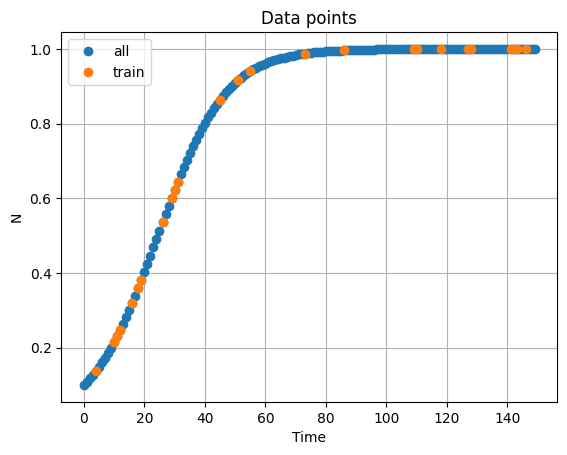

layers: [1, 10, 10, 1]
It: 0, Loss: 7.922e-01, pinn loss: 3.697e-06, data loss: 7.922e-01, r: 0.010, K: 1.000000
Loss: 3.004e-07, pinn loss: 5.184e-08, data loss: 2.485e-07, r: 0.090, K: 1.000000


 19%|█▉        | 19/100 [00:41<03:14,  2.40s/it]

estimated alpha:  0.08958079665899277
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


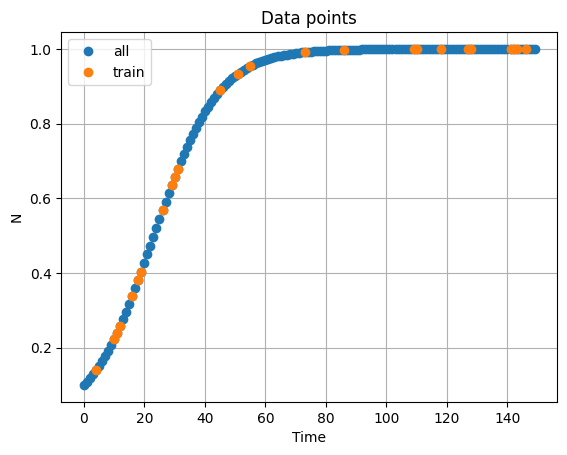

layers: [1, 10, 10, 1]
It: 0, Loss: 4.292e-01, pinn loss: 8.104e-07, data loss: 4.292e-01, r: 0.010, K: 1.000000


 20%|██        | 20/100 [00:44<03:10,  2.38s/it]

Loss: 1.076e-06, pinn loss: 1.459e-07, data loss: 9.302e-07, r: 0.095, K: 1.000000
estimated alpha:  0.09530335664749146
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


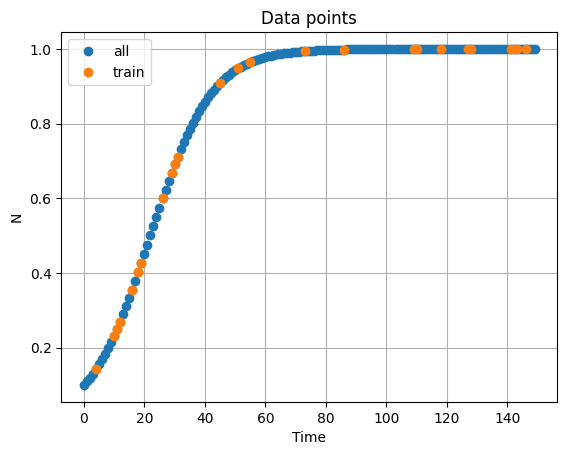

layers: [1, 10, 10, 1]
It: 0, Loss: 9.062e-01, pinn loss: 6.844e-06, data loss: 9.062e-01, r: 0.010, K: 1.000000
Loss: 1.567e-05, pinn loss: 1.322e-06, data loss: 1.435e-05, r: 0.100, K: 1.000000


 21%|██        | 21/100 [00:46<03:18,  2.52s/it]

estimated alpha:  0.09996892511844635
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


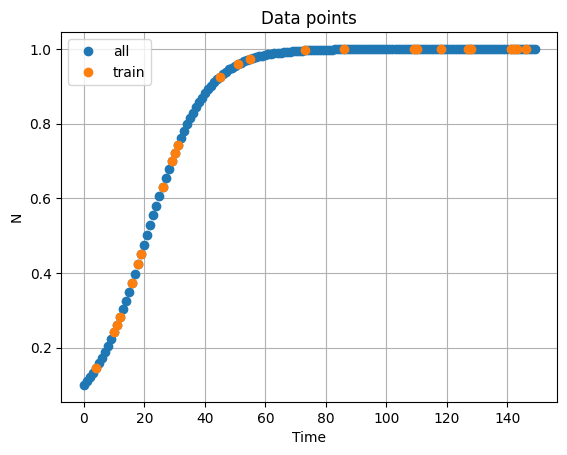

layers: [1, 10, 10, 1]
It: 0, Loss: 6.038e-01, pinn loss: 1.967e-07, data loss: 6.038e-01, r: 0.010, K: 1.000000
Loss: 4.300e-07, pinn loss: 1.637e-08, data loss: 4.136e-07, r: 0.105, K: 1.000000


 22%|██▏       | 22/100 [00:49<03:12,  2.46s/it]

estimated alpha:  0.10508982092142105
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


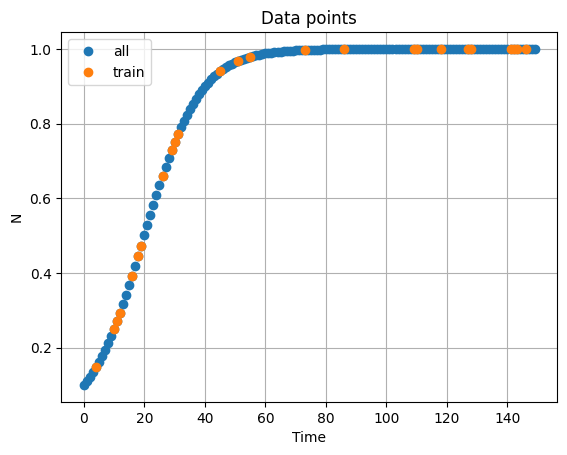

layers: [1, 10, 10, 1]
It: 0, Loss: 6.871e-01, pinn loss: 8.359e-07, data loss: 6.871e-01, r: 0.010, K: 1.000000
Loss: 2.552e-07, pinn loss: 1.729e-08, data loss: 2.379e-07, r: 0.110, K: 1.000000


 23%|██▎       | 23/100 [00:51<03:07,  2.44s/it]

estimated alpha:  0.110073022544384
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


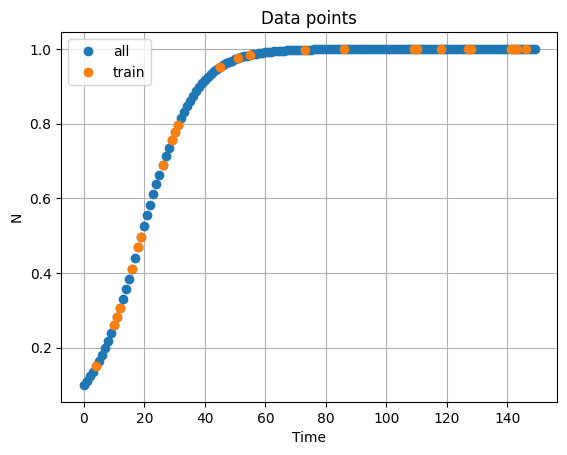

layers: [1, 10, 10, 1]
It: 0, Loss: 8.067e-01, pinn loss: 1.342e-06, data loss: 8.067e-01, r: 0.010, K: 1.000000


 24%|██▍       | 24/100 [00:53<02:56,  2.32s/it]

estimated alpha:  0.11427102982997894
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


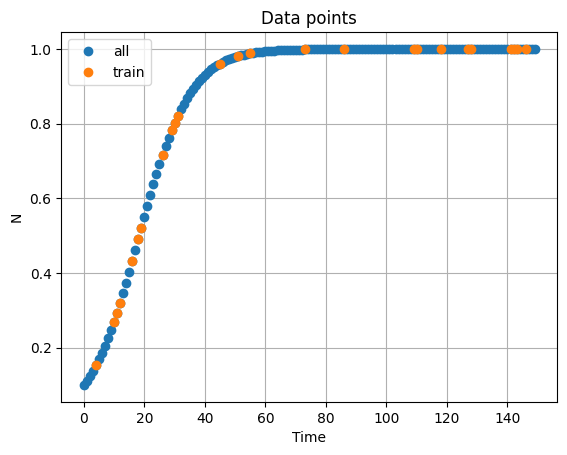

layers: [1, 10, 10, 1]
It: 0, Loss: 6.462e-01, pinn loss: 9.445e-08, data loss: 6.462e-01, r: 0.010, K: 1.000000
Loss: 1.514e-06, pinn loss: 7.288e-08, data loss: 1.441e-06, r: 0.120, K: 1.000000


 25%|██▌       | 25/100 [00:56<03:07,  2.50s/it]

estimated alpha:  0.11972785741090775
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


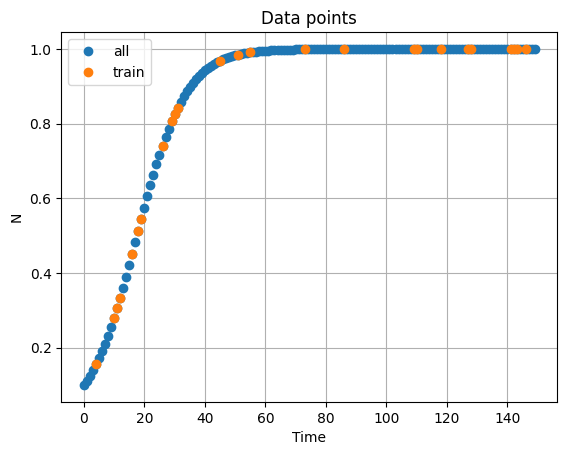

layers: [1, 10, 10, 1]
It: 0, Loss: 2.370e-01, pinn loss: 7.635e-06, data loss: 2.370e-01, r: 0.010, K: 1.000000
Loss: 5.628e-07, pinn loss: 1.247e-07, data loss: 4.381e-07, r: 0.124, K: 1.000000


 26%|██▌       | 26/100 [00:58<03:02,  2.47s/it]

estimated alpha:  0.1250036656856537
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


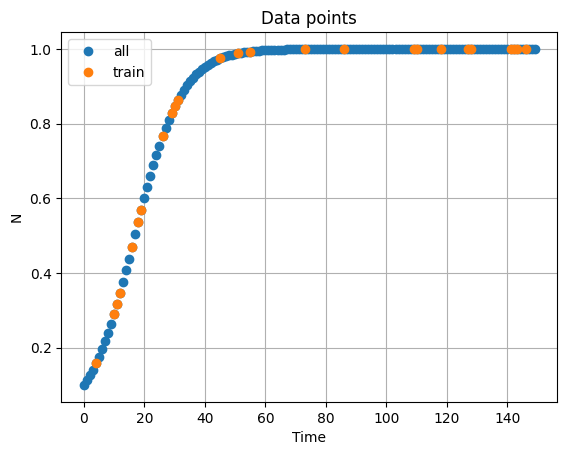

layers: [1, 10, 10, 1]
It: 0, Loss: 3.174e-01, pinn loss: 6.595e-06, data loss: 3.174e-01, r: 0.010, K: 1.000000
Loss: 2.417e-04, pinn loss: 7.698e-05, data loss: 1.647e-04, r: 0.033, K: 1.000000
Loss: 5.309e-07, pinn loss: 2.643e-08, data loss: 5.045e-07, r: 0.131, K: 1.000000


 27%|██▋       | 27/100 [01:02<03:22,  2.77s/it]

estimated alpha:  0.13016918301582336
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


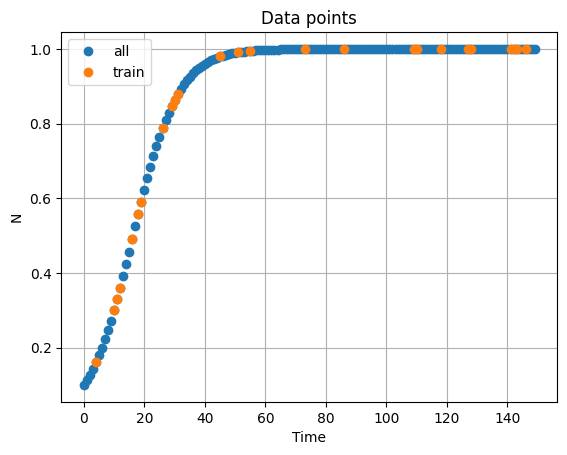

layers: [1, 10, 10, 1]
It: 0, Loss: 8.805e-01, pinn loss: 3.126e-06, data loss: 8.805e-01, r: 0.010, K: 1.000000


 28%|██▊       | 28/100 [01:04<03:03,  2.55s/it]

Loss: 2.626e-07, pinn loss: 1.728e-08, data loss: 2.454e-07, r: 0.135, K: 1.000000
estimated alpha:  0.13497038185596466
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


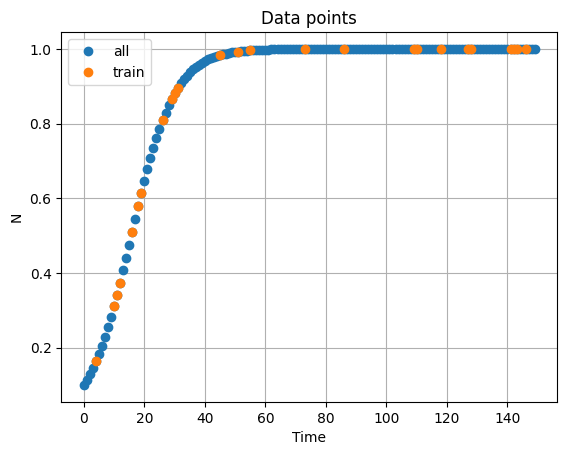

layers: [1, 10, 10, 1]
It: 0, Loss: 1.254e+00, pinn loss: 1.183e-05, data loss: 1.254e+00, r: 0.010, K: 1.000000
Loss: 8.852e-07, pinn loss: 1.654e-07, data loss: 7.197e-07, r: 0.140, K: 1.000000
Loss: 1.110e-07, pinn loss: 3.587e-08, data loss: 7.508e-08, r: 0.140, K: 1.000000


 29%|██▉       | 29/100 [01:08<03:33,  3.01s/it]

estimated alpha:  0.14012005925178528
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


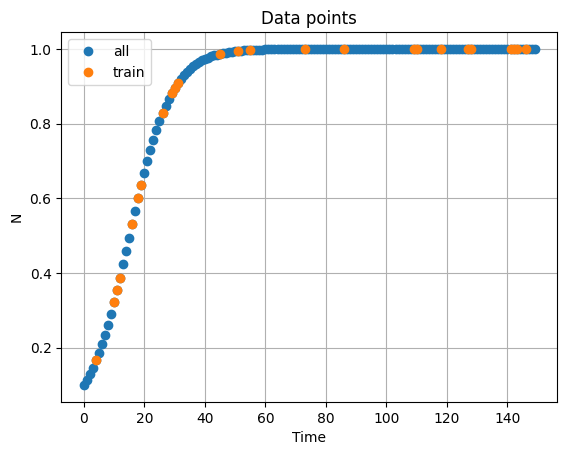

layers: [1, 10, 10, 1]
It: 0, Loss: 3.963e-01, pinn loss: 2.186e-08, data loss: 3.963e-01, r: 0.010, K: 1.000000
Loss: 8.339e-05, pinn loss: 1.099e-05, data loss: 7.240e-05, r: 0.147, K: 1.000000


 30%|███       | 30/100 [01:11<03:35,  3.08s/it]

Loss: 2.314e-08, pinn loss: 1.305e-08, data loss: 1.009e-08, r: 0.145, K: 1.000000
estimated alpha:  0.14476731419563293
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


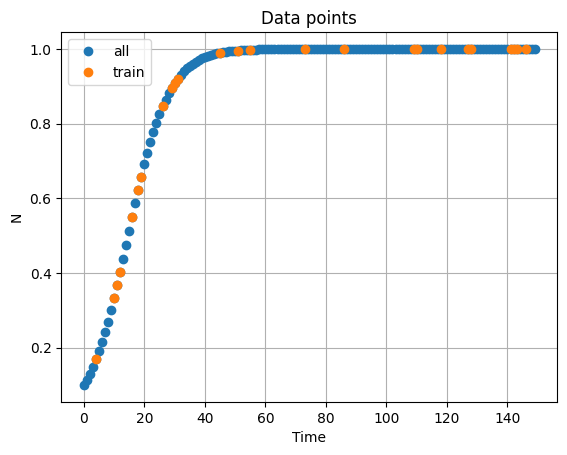

layers: [1, 10, 10, 1]
It: 0, Loss: 5.910e-01, pinn loss: 1.557e-06, data loss: 5.910e-01, r: 0.010, K: 1.000000
Loss: 1.156e-05, pinn loss: 4.344e-06, data loss: 7.218e-06, r: 0.148, K: 1.000000


 31%|███       | 31/100 [01:14<03:33,  3.10s/it]

Loss: 1.689e-07, pinn loss: 4.285e-08, data loss: 1.261e-07, r: 0.150, K: 1.000000
estimated alpha:  0.15019577741622925
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


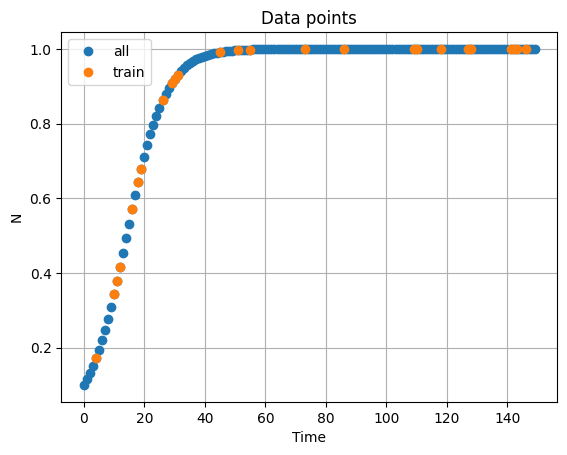

layers: [1, 10, 10, 1]
It: 0, Loss: 1.398e+00, pinn loss: 1.886e-05, data loss: 1.398e+00, r: 0.010, K: 1.000000
Loss: 2.065e-05, pinn loss: 2.881e-06, data loss: 1.777e-05, r: 0.158, K: 1.000000


 32%|███▏      | 32/100 [01:17<03:19,  2.94s/it]

estimated alpha:  0.153794527053833
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


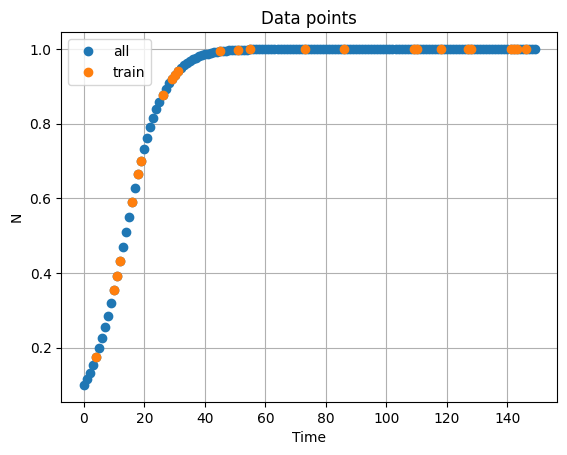

layers: [1, 10, 10, 1]
It: 0, Loss: 1.808e+00, pinn loss: 5.022e-05, data loss: 1.808e+00, r: 0.010, K: 1.000000
Loss: 3.692e-05, pinn loss: 1.508e-05, data loss: 2.184e-05, r: 0.149, K: 1.000000


 33%|███▎      | 33/100 [01:20<03:11,  2.85s/it]

estimated alpha:  0.15701501071453094
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


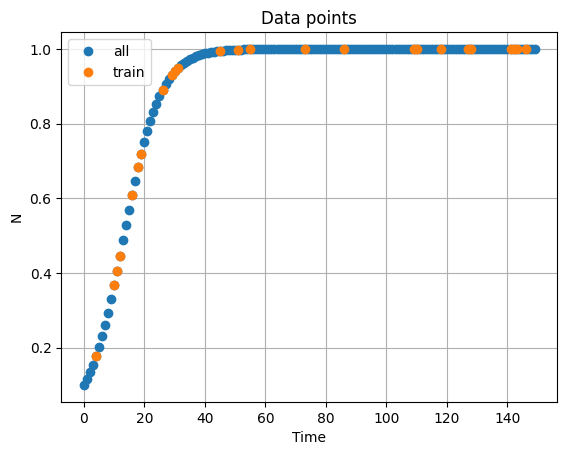

layers: [1, 10, 10, 1]
It: 0, Loss: 1.629e+00, pinn loss: 2.830e-05, data loss: 1.629e+00, r: 0.010, K: 1.000000
Loss: 7.573e-04, pinn loss: 1.187e-04, data loss: 6.386e-04, r: 0.153, K: 1.000000
Loss: 8.186e-05, pinn loss: 8.264e-06, data loss: 7.360e-05, r: 0.149, K: 1.000000
Loss: 3.113e-06, pinn loss: 9.807e-07, data loss: 2.132e-06, r: 0.162, K: 1.000000
Loss: 6.602e-07, pinn loss: 1.070e-07, data loss: 5.531e-07, r: 0.166, K: 1.000000


 34%|███▍      | 34/100 [01:26<04:13,  3.84s/it]

estimated alpha:  0.16509848833084106
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


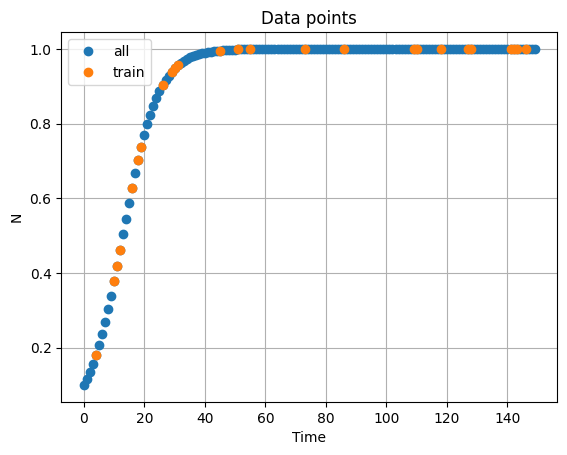

layers: [1, 10, 10, 1]
It: 0, Loss: 7.570e-01, pinn loss: 1.786e-07, data loss: 7.570e-01, r: 0.010, K: 1.000000
Loss: 4.452e-06, pinn loss: 6.623e-07, data loss: 3.790e-06, r: 0.166, K: 1.000000


 35%|███▌      | 35/100 [01:29<03:49,  3.54s/it]

estimated alpha:  0.169631227850914
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


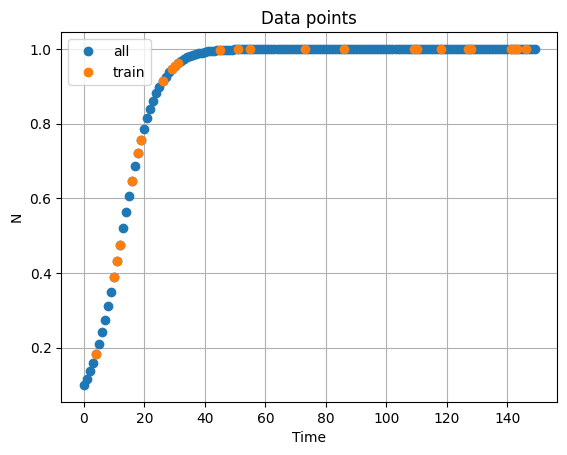

layers: [1, 10, 10, 1]
It: 0, Loss: 1.254e+00, pinn loss: 5.782e-06, data loss: 1.254e+00, r: 0.010, K: 1.000000
Loss: 1.532e-04, pinn loss: 2.955e-05, data loss: 1.237e-04, r: 0.180, K: 1.000000
Loss: 8.876e-07, pinn loss: 6.146e-08, data loss: 8.262e-07, r: 0.176, K: 1.000000


 36%|███▌      | 36/100 [01:33<04:01,  3.77s/it]

estimated alpha:  0.17504236102104187
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


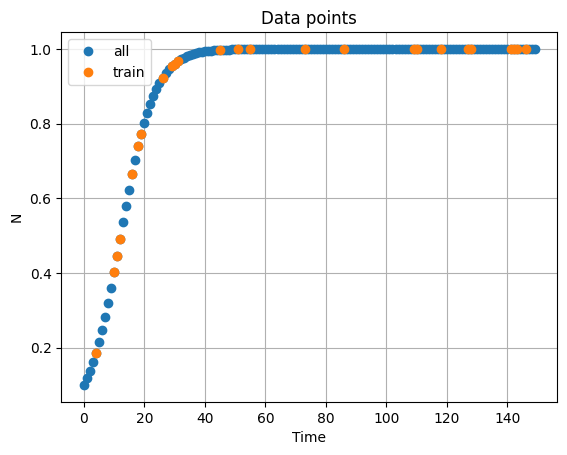

layers: [1, 10, 10, 1]
It: 0, Loss: 5.286e-01, pinn loss: 1.242e-06, data loss: 5.286e-01, r: 0.010, K: 1.000000
Loss: 5.429e-05, pinn loss: 4.875e-06, data loss: 4.941e-05, r: 0.180, K: 1.000000


 37%|███▋      | 37/100 [01:36<03:37,  3.45s/it]

estimated alpha:  0.17768916487693787
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


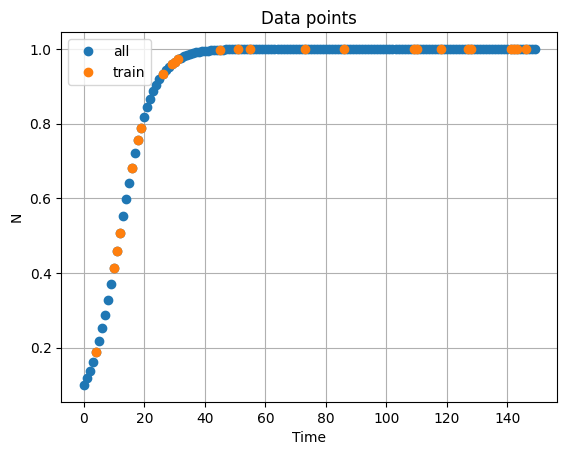

layers: [1, 10, 10, 1]
It: 0, Loss: 1.300e+00, pinn loss: 8.060e-06, data loss: 1.300e+00, r: 0.010, K: 1.000000
Loss: 1.238e-04, pinn loss: 9.614e-06, data loss: 1.142e-04, r: 0.203, K: 1.000000
Loss: 9.037e-07, pinn loss: 2.199e-07, data loss: 6.838e-07, r: 0.185, K: 1.000000
Loss: 1.668e-07, pinn loss: 3.997e-08, data loss: 1.268e-07, r: 0.185, K: 1.000000


 38%|███▊      | 38/100 [01:40<03:54,  3.78s/it]

estimated alpha:  0.1851654201745987
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


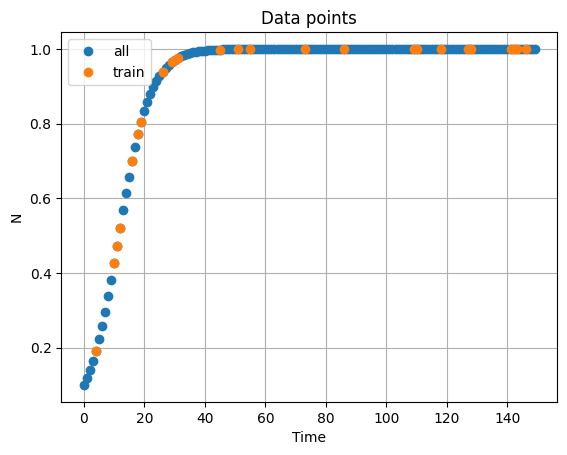

layers: [1, 10, 10, 1]
It: 0, Loss: 4.672e-01, pinn loss: 1.350e-06, data loss: 4.672e-01, r: 0.010, K: 1.000000
Loss: 2.081e-04, pinn loss: 2.868e-05, data loss: 1.794e-04, r: 0.181, K: 1.000000
Loss: 1.577e-07, pinn loss: 2.897e-08, data loss: 1.287e-07, r: 0.190, K: 1.000000


 39%|███▉      | 39/100 [01:44<03:56,  3.88s/it]

estimated alpha:  0.19020631909370422
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


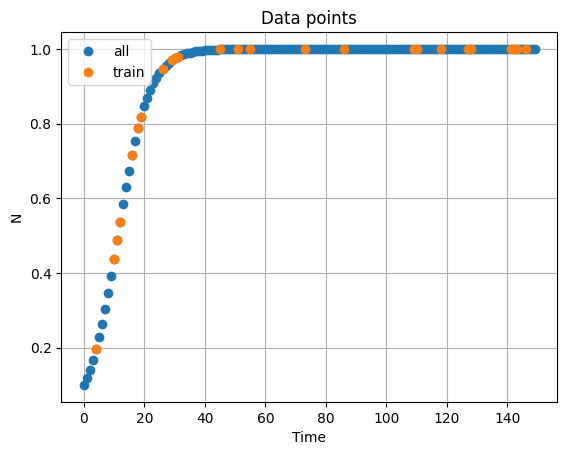

layers: [1, 10, 10, 1]
It: 0, Loss: 7.817e-01, pinn loss: 1.437e-06, data loss: 7.817e-01, r: 0.010, K: 1.000000
Loss: 9.870e-05, pinn loss: 2.311e-05, data loss: 7.559e-05, r: 0.209, K: 1.000000


 40%|████      | 40/100 [01:47<03:39,  3.66s/it]

Loss: 3.164e-07, pinn loss: 1.274e-07, data loss: 1.890e-07, r: 0.195, K: 1.000000
estimated alpha:  0.19514909386634827
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


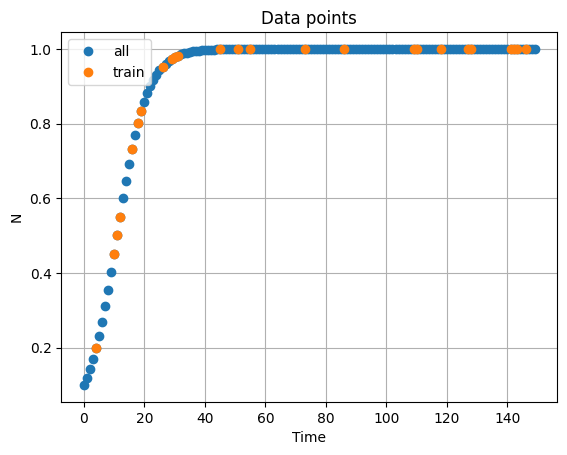

layers: [1, 10, 10, 1]
It: 0, Loss: 8.598e-01, pinn loss: 5.310e-07, data loss: 8.598e-01, r: 0.010, K: 1.000000
Loss: 2.014e-06, pinn loss: 9.332e-07, data loss: 1.081e-06, r: 0.203, K: 1.000000


 41%|████      | 41/100 [01:50<03:15,  3.31s/it]

estimated alpha:  0.20069707930088043
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


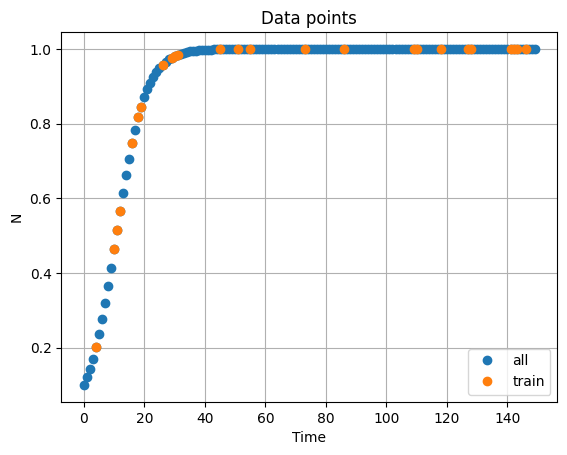

layers: [1, 10, 10, 1]
It: 0, Loss: 8.832e-01, pinn loss: 1.202e-06, data loss: 8.832e-01, r: 0.010, K: 1.000000
Loss: 4.300e-06, pinn loss: 2.143e-06, data loss: 2.157e-06, r: 0.217, K: 1.000000
Loss: 1.357e-06, pinn loss: 8.370e-07, data loss: 5.204e-07, r: 0.202, K: 1.000000


 42%|████▏     | 42/100 [01:55<03:37,  3.74s/it]

Loss: 8.484e-08, pinn loss: 1.359e-08, data loss: 7.125e-08, r: 0.205, K: 1.000000
estimated alpha:  0.20491471886634827
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


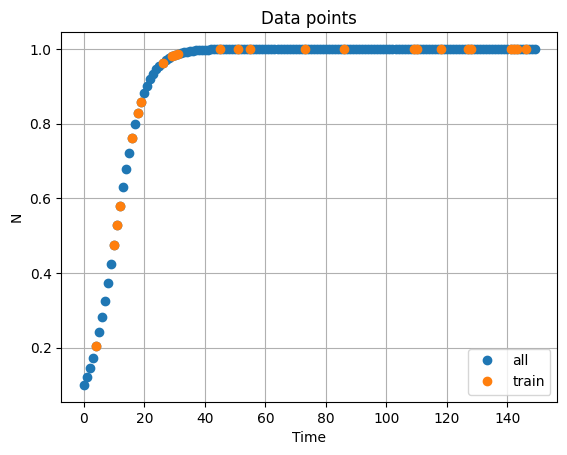

layers: [1, 10, 10, 1]
It: 0, Loss: 4.159e-01, pinn loss: 6.075e-07, data loss: 4.159e-01, r: 0.010, K: 1.000000
Loss: 2.735e-04, pinn loss: 2.983e-05, data loss: 2.437e-04, r: 0.187, K: 1.000000
Loss: 6.581e-07, pinn loss: 8.524e-08, data loss: 5.729e-07, r: 0.211, K: 1.000000
Loss: 4.586e-08, pinn loss: 3.032e-08, data loss: 1.554e-08, r: 0.210, K: 1.000000


 43%|████▎     | 43/100 [02:00<03:54,  4.12s/it]

estimated alpha:  0.21002689003944397
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


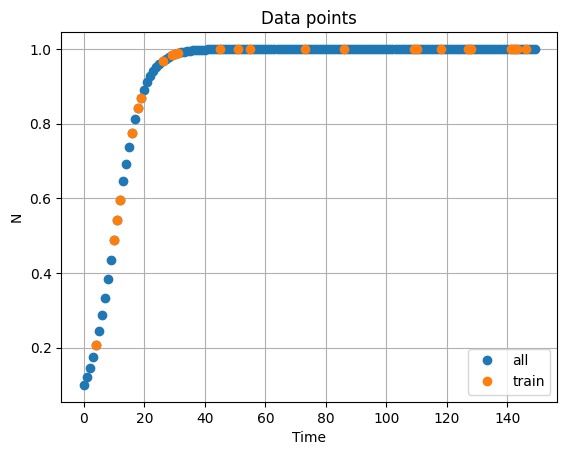

layers: [1, 10, 10, 1]
It: 0, Loss: 3.899e-01, pinn loss: 3.184e-06, data loss: 3.899e-01, r: 0.010, K: 1.000000
Loss: 6.321e-04, pinn loss: 2.047e-04, data loss: 4.273e-04, r: 0.179, K: 1.000000
Loss: 3.491e-04, pinn loss: 5.102e-05, data loss: 2.981e-04, r: 0.217, K: 1.000000
Loss: 1.928e-05, pinn loss: 3.746e-06, data loss: 1.553e-05, r: 0.199, K: 1.000000


 44%|████▍     | 44/100 [02:04<03:58,  4.25s/it]

estimated alpha:  0.21209748089313507
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


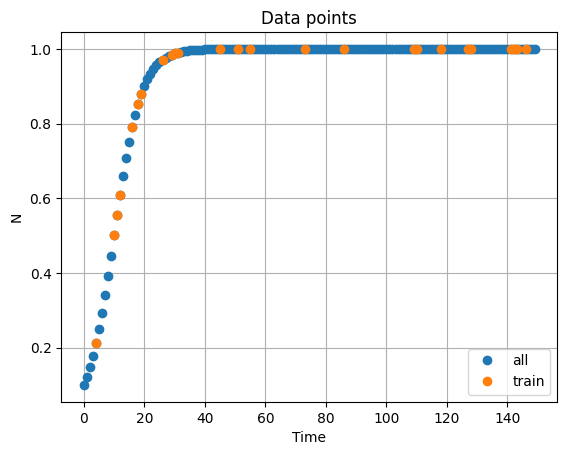

layers: [1, 10, 10, 1]
It: 0, Loss: 5.126e-01, pinn loss: 4.493e-06, data loss: 5.126e-01, r: 0.010, K: 1.000000
Loss: 1.092e-04, pinn loss: 2.024e-05, data loss: 8.897e-05, r: 0.223, K: 1.000000
Loss: 1.332e-06, pinn loss: 1.892e-07, data loss: 1.143e-06, r: 0.220, K: 1.000000


 45%|████▌     | 45/100 [02:08<03:49,  4.18s/it]

estimated alpha:  0.21985219419002533
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


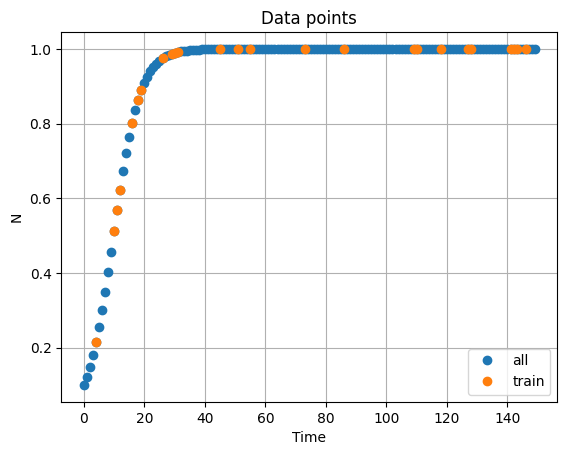

layers: [1, 10, 10, 1]
It: 0, Loss: 1.141e+00, pinn loss: 5.853e-06, data loss: 1.141e+00, r: 0.010, K: 1.000000
Loss: 1.617e-05, pinn loss: 1.333e-06, data loss: 1.483e-05, r: 0.225, K: 1.000000


 46%|████▌     | 46/100 [02:11<03:23,  3.76s/it]

estimated alpha:  0.2246023267507553
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


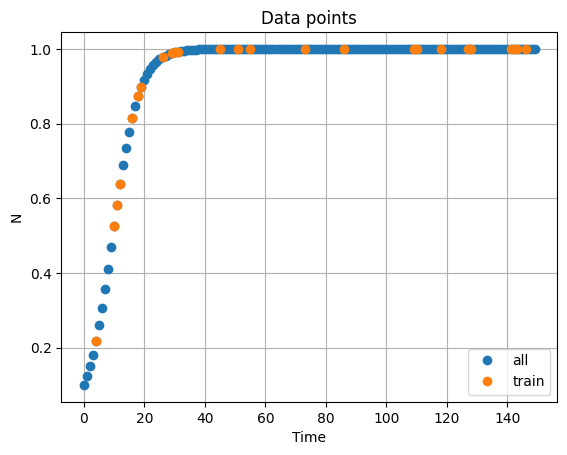

layers: [1, 10, 10, 1]
It: 0, Loss: 2.126e-01, pinn loss: 4.229e-06, data loss: 2.126e-01, r: 0.010, K: 1.000000
Loss: 1.393e-05, pinn loss: 7.247e-06, data loss: 6.681e-06, r: 0.217, K: 1.000000
Loss: 7.208e-07, pinn loss: 2.261e-07, data loss: 4.947e-07, r: 0.229, K: 1.000000
Loss: 1.462e-07, pinn loss: 5.422e-08, data loss: 9.202e-08, r: 0.230, K: 1.000000


 47%|████▋     | 47/100 [02:16<03:34,  4.05s/it]

estimated alpha:  0.22965601086616516
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


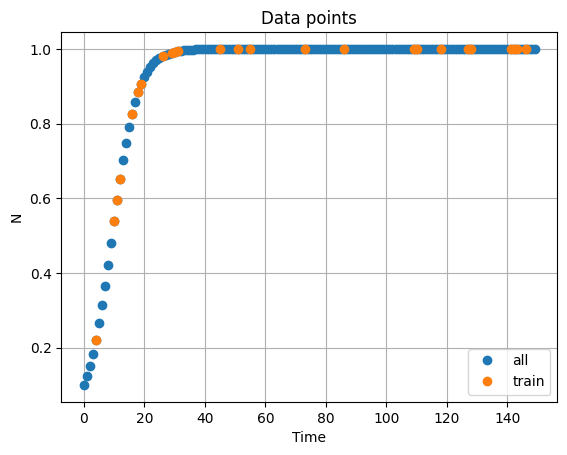

layers: [1, 10, 10, 1]
It: 0, Loss: 4.370e-01, pinn loss: 6.620e-06, data loss: 4.369e-01, r: 0.010, K: 1.000000
Loss: 2.913e-05, pinn loss: 2.716e-06, data loss: 2.641e-05, r: 0.238, K: 1.000000


 48%|████▊     | 48/100 [02:19<03:20,  3.85s/it]

estimated alpha:  0.2348364293575287
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


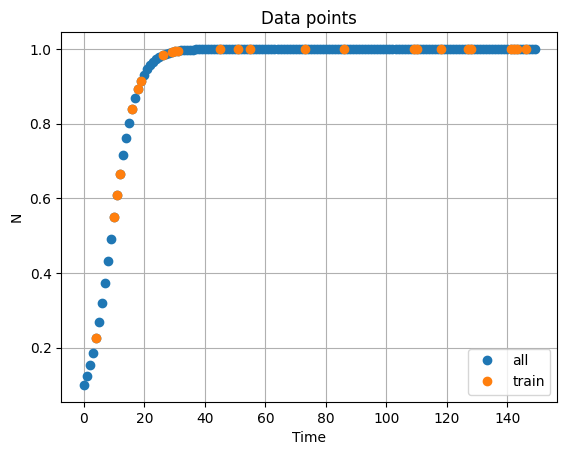

layers: [1, 10, 10, 1]
It: 0, Loss: 5.690e-01, pinn loss: 5.959e-07, data loss: 5.690e-01, r: 0.010, K: 1.000000
Loss: 2.579e-06, pinn loss: 4.145e-07, data loss: 2.164e-06, r: 0.238, K: 1.000000


 49%|████▉     | 49/100 [02:22<02:53,  3.40s/it]

estimated alpha:  0.23768913745880127
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


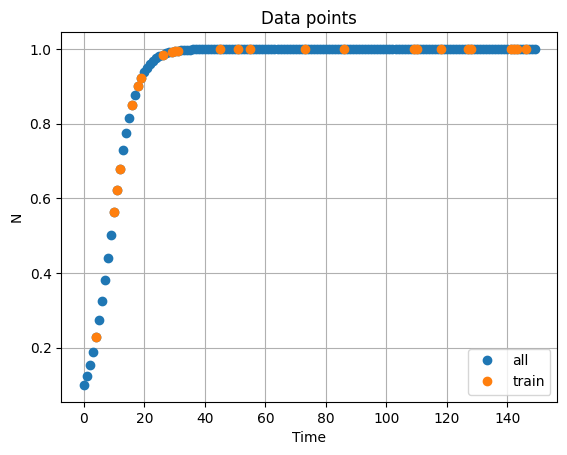

layers: [1, 10, 10, 1]
It: 0, Loss: 1.077e+00, pinn loss: 2.131e-06, data loss: 1.077e+00, r: 0.010, K: 1.000000
Loss: 2.210e-04, pinn loss: 8.657e-05, data loss: 1.344e-04, r: 0.248, K: 1.000000


 50%|█████     | 50/100 [02:25<02:47,  3.36s/it]

Loss: 3.312e-07, pinn loss: 2.101e-07, data loss: 1.211e-07, r: 0.244, K: 1.000000
estimated alpha:  0.24457770586013794
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


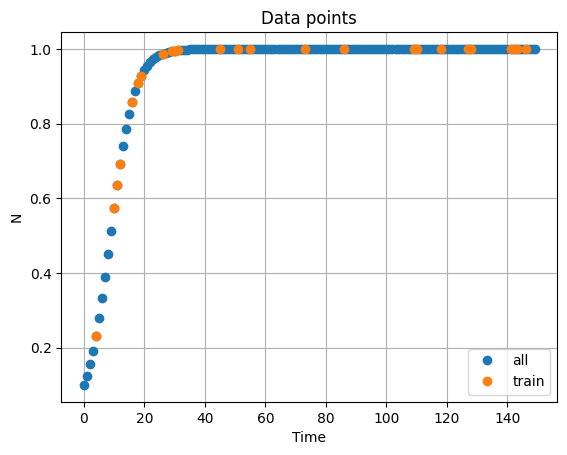

layers: [1, 10, 10, 1]
It: 0, Loss: 3.985e-01, pinn loss: 7.765e-06, data loss: 3.985e-01, r: 0.010, K: 1.000000
Loss: 3.068e-05, pinn loss: 7.436e-06, data loss: 2.324e-05, r: 0.253, K: 1.000000


 51%|█████     | 51/100 [02:28<02:37,  3.22s/it]

estimated alpha:  0.24898935854434967
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


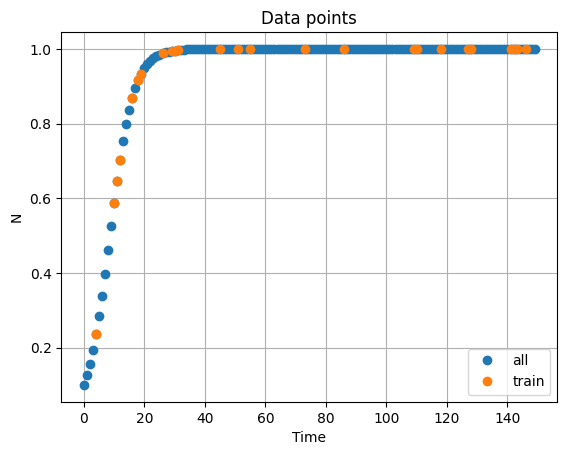

layers: [1, 10, 10, 1]
It: 0, Loss: 4.581e-01, pinn loss: 4.524e-06, data loss: 4.581e-01, r: 0.010, K: 1.000000
Loss: 4.603e-05, pinn loss: 2.865e-05, data loss: 1.739e-05, r: 0.269, K: 1.000000


 52%|█████▏    | 52/100 [02:31<02:29,  3.12s/it]

estimated alpha:  0.2547069787979126
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


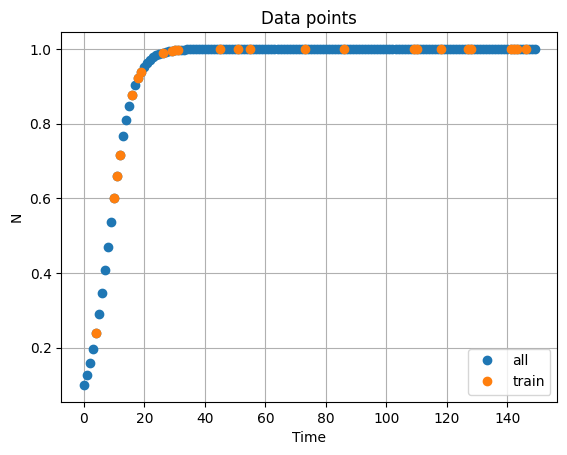

layers: [1, 10, 10, 1]
It: 0, Loss: 1.217e+00, pinn loss: 3.199e-06, data loss: 1.217e+00, r: 0.010, K: 1.000000
Loss: 3.098e-04, pinn loss: 1.788e-04, data loss: 1.310e-04, r: 0.183, K: 1.000000
Loss: 5.465e-05, pinn loss: 2.466e-05, data loss: 2.999e-05, r: 0.261, K: 1.000000


 53%|█████▎    | 53/100 [02:35<02:47,  3.56s/it]

Loss: 7.134e-06, pinn loss: 2.613e-06, data loss: 4.522e-06, r: 0.255, K: 1.000000
estimated alpha:  0.254650354385376
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


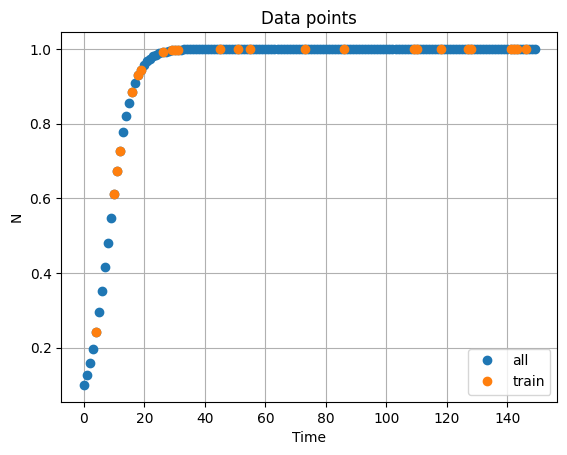

layers: [1, 10, 10, 1]
It: 0, Loss: 4.504e-01, pinn loss: 1.122e-05, data loss: 4.504e-01, r: 0.010, K: 1.000000
Loss: 1.268e-02, pinn loss: 1.186e-03, data loss: 1.150e-02, r: 0.348, K: 1.000000


 54%|█████▍    | 54/100 [02:38<02:35,  3.38s/it]

estimated alpha:  0.26327377557754517
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


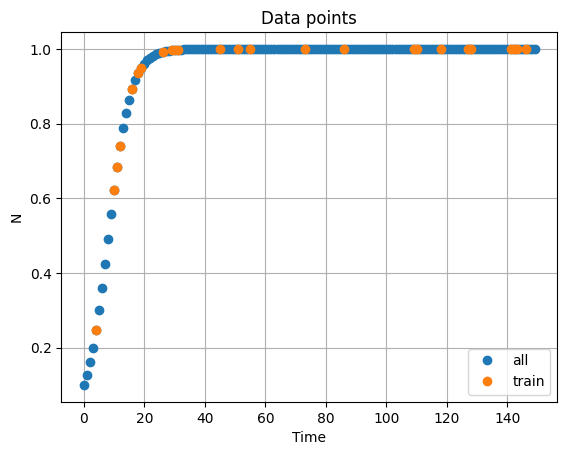

layers: [1, 10, 10, 1]
It: 0, Loss: 4.145e-01, pinn loss: 3.690e-06, data loss: 4.145e-01, r: 0.010, K: 1.000000
Loss: 1.944e-04, pinn loss: 9.560e-05, data loss: 9.880e-05, r: 0.261, K: 1.000000
Loss: 2.560e-06, pinn loss: 5.355e-07, data loss: 2.025e-06, r: 0.269, K: 1.000000


 55%|█████▌    | 55/100 [02:43<02:50,  3.79s/it]

Loss: 1.108e-07, pinn loss: 4.831e-08, data loss: 6.247e-08, r: 0.270, K: 1.000000
estimated alpha:  0.26970377564430237
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


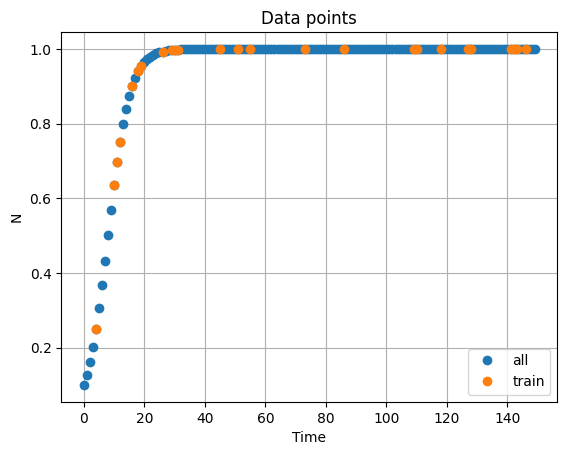

layers: [1, 10, 10, 1]
It: 0, Loss: 1.326e+00, pinn loss: 7.821e-06, data loss: 1.326e+00, r: 0.010, K: 1.000000
Loss: 9.268e-06, pinn loss: 3.776e-06, data loss: 5.492e-06, r: 0.269, K: 1.000000


 56%|█████▌    | 56/100 [02:46<02:32,  3.46s/it]

estimated alpha:  0.27392542362213135
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


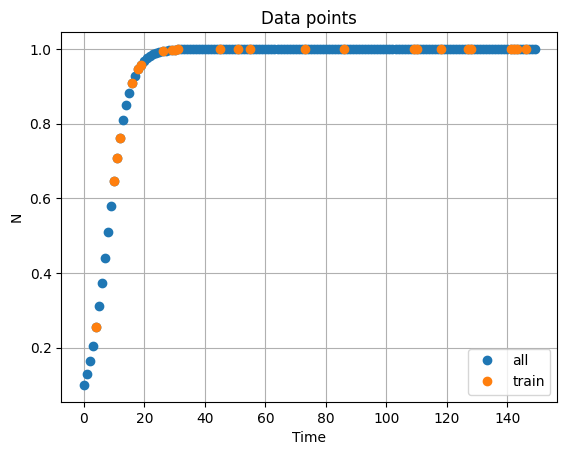

layers: [1, 10, 10, 1]
It: 0, Loss: 9.248e-01, pinn loss: 2.158e-09, data loss: 9.248e-01, r: 0.010, K: 1.000000
Loss: 3.865e-04, pinn loss: 1.620e-04, data loss: 2.245e-04, r: 0.245, K: 1.000000
Loss: 5.163e-06, pinn loss: 7.007e-07, data loss: 4.463e-06, r: 0.288, K: 1.000000


 57%|█████▋    | 57/100 [02:49<02:29,  3.47s/it]

estimated alpha:  0.2792811989784241
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


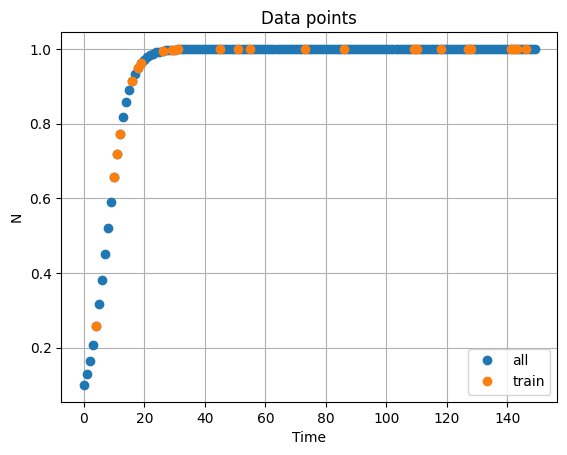

layers: [1, 10, 10, 1]
It: 0, Loss: 1.114e+00, pinn loss: 1.698e-06, data loss: 1.114e+00, r: 0.010, K: 1.000000
Loss: 1.592e-04, pinn loss: 9.730e-05, data loss: 6.187e-05, r: 0.293, K: 1.000000
Loss: 1.282e-06, pinn loss: 5.693e-07, data loss: 7.127e-07, r: 0.284, K: 1.000000
Loss: 5.068e-07, pinn loss: 2.170e-07, data loss: 2.898e-07, r: 0.286, K: 1.000000


 58%|█████▊    | 58/100 [02:54<02:46,  3.97s/it]

estimated alpha:  0.2841409742832184
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


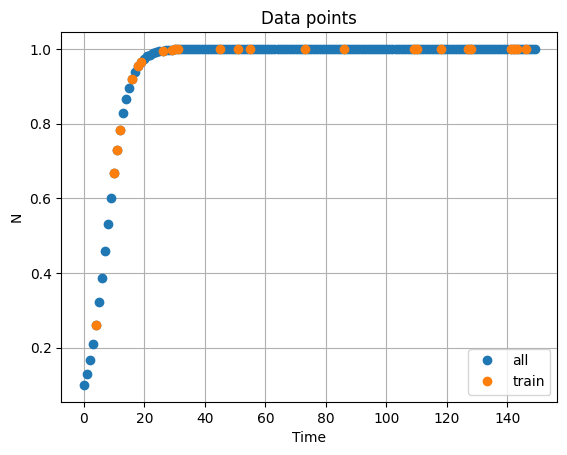

layers: [1, 10, 10, 1]
It: 0, Loss: 1.911e+00, pinn loss: 3.565e-05, data loss: 1.911e+00, r: 0.010, K: 1.000000
Loss: 1.656e-04, pinn loss: 1.081e-04, data loss: 5.750e-05, r: 0.297, K: 1.000000
Loss: 6.761e-06, pinn loss: 2.184e-06, data loss: 4.577e-06, r: 0.293, K: 1.000000


 59%|█████▉    | 59/100 [02:58<02:44,  4.01s/it]

estimated alpha:  0.2901454567909241
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


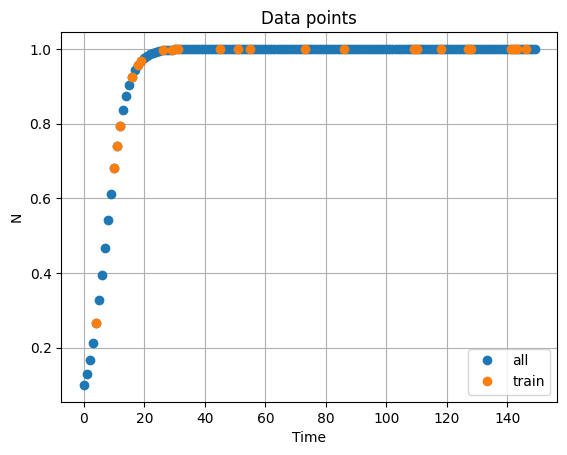

layers: [1, 10, 10, 1]
It: 0, Loss: 1.842e-01, pinn loss: 5.578e-06, data loss: 1.842e-01, r: 0.010, K: 1.000000
Loss: 3.421e-05, pinn loss: 1.504e-05, data loss: 1.917e-05, r: 0.306, K: 1.000000


 60%|██████    | 60/100 [03:01<02:22,  3.55s/it]

estimated alpha:  0.29509609937667847
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


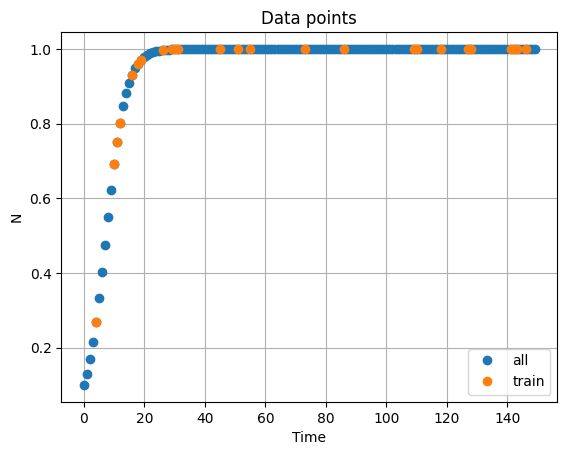

layers: [1, 10, 10, 1]
It: 0, Loss: 1.358e+00, pinn loss: 7.954e-06, data loss: 1.358e+00, r: 0.010, K: 1.000000
Loss: 2.661e-05, pinn loss: 6.897e-06, data loss: 1.971e-05, r: 0.311, K: 1.000000


 61%|██████    | 61/100 [03:04<02:14,  3.44s/it]

Loss: 3.075e-06, pinn loss: 9.669e-07, data loss: 2.108e-06, r: 0.301, K: 1.000000
estimated alpha:  0.30094054341316223
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


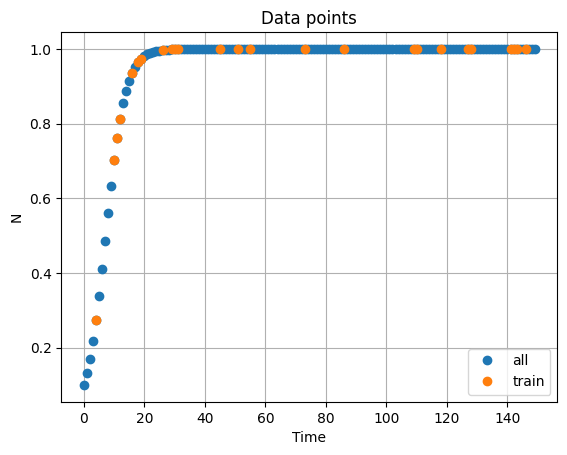

layers: [1, 10, 10, 1]
It: 0, Loss: 7.944e-01, pinn loss: 2.983e-06, data loss: 7.944e-01, r: 0.010, K: 1.000000
Loss: 1.991e-04, pinn loss: 5.209e-05, data loss: 1.470e-04, r: 0.323, K: 1.000000
Loss: 1.083e-06, pinn loss: 2.850e-07, data loss: 7.978e-07, r: 0.303, K: 1.000000


 62%|██████▏   | 62/100 [03:08<02:19,  3.67s/it]

estimated alpha:  0.3038542568683624
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


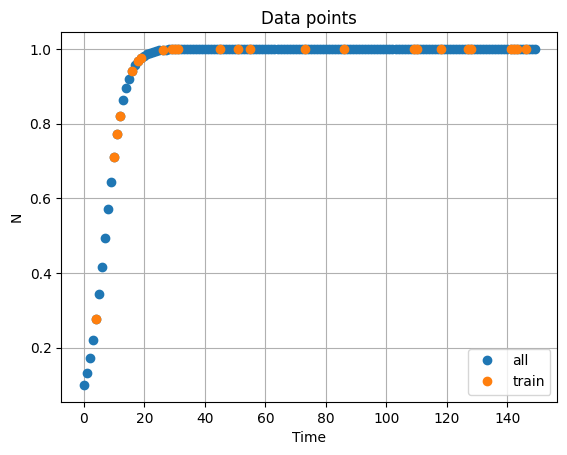

layers: [1, 10, 10, 1]
It: 0, Loss: 1.051e+00, pinn loss: 4.731e-06, data loss: 1.051e+00, r: 0.010, K: 1.000000
Loss: 3.085e-04, pinn loss: 1.652e-04, data loss: 1.433e-04, r: 0.313, K: 1.000000


 63%|██████▎   | 63/100 [03:11<02:06,  3.41s/it]

estimated alpha:  0.31057852506637573
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


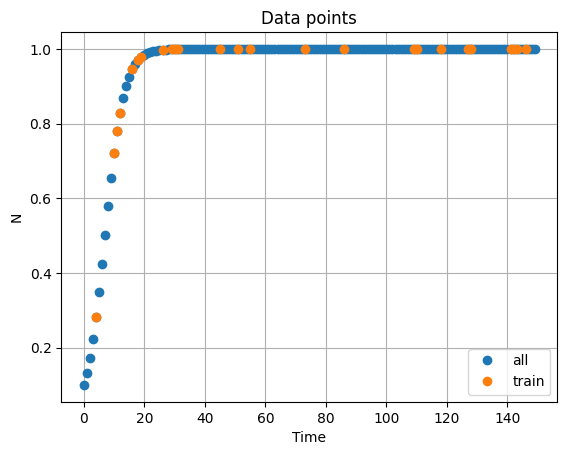

layers: [1, 10, 10, 1]
It: 0, Loss: 1.351e+00, pinn loss: 6.530e-06, data loss: 1.351e+00, r: 0.010, K: 1.000000
Loss: 3.622e-04, pinn loss: 2.036e-04, data loss: 1.585e-04, r: 0.339, K: 1.000000
Loss: 7.807e-06, pinn loss: 4.564e-06, data loss: 3.243e-06, r: 0.319, K: 1.000000


 64%|██████▍   | 64/100 [03:14<02:01,  3.39s/it]

estimated alpha:  0.3186476230621338
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


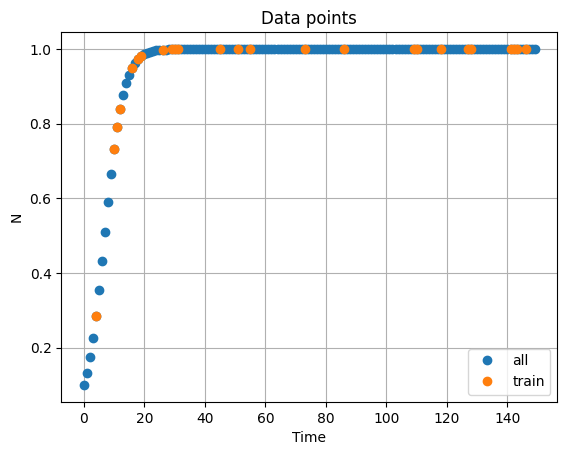

layers: [1, 10, 10, 1]
It: 0, Loss: 6.162e-01, pinn loss: 3.893e-06, data loss: 6.162e-01, r: 0.010, K: 1.000000
Loss: 1.135e-04, pinn loss: 6.764e-05, data loss: 4.585e-05, r: 0.327, K: 1.000000


 65%|██████▌   | 65/100 [03:17<01:54,  3.27s/it]

estimated alpha:  0.3233911395072937
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


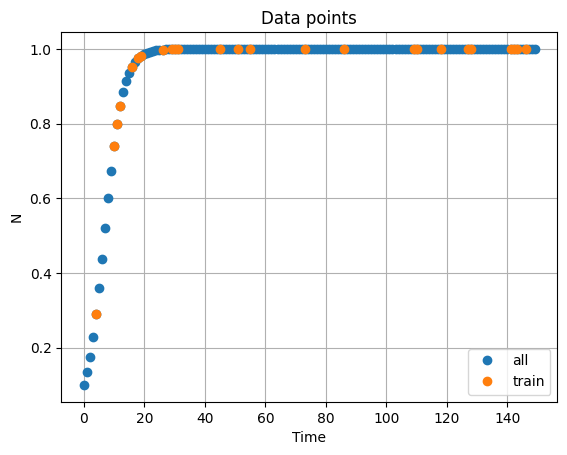

layers: [1, 10, 10, 1]
It: 0, Loss: 1.180e+00, pinn loss: 1.043e-06, data loss: 1.180e+00, r: 0.010, K: 1.000000
Loss: 5.704e-04, pinn loss: 3.633e-04, data loss: 2.072e-04, r: 0.226, K: 1.000000
Loss: 7.773e-05, pinn loss: 2.571e-05, data loss: 5.203e-05, r: 0.325, K: 1.000000


 66%|██████▌   | 66/100 [03:22<02:05,  3.70s/it]

Loss: 2.257e-06, pinn loss: 1.603e-06, data loss: 6.539e-07, r: 0.329, K: 1.000000
estimated alpha:  0.3287312090396881
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


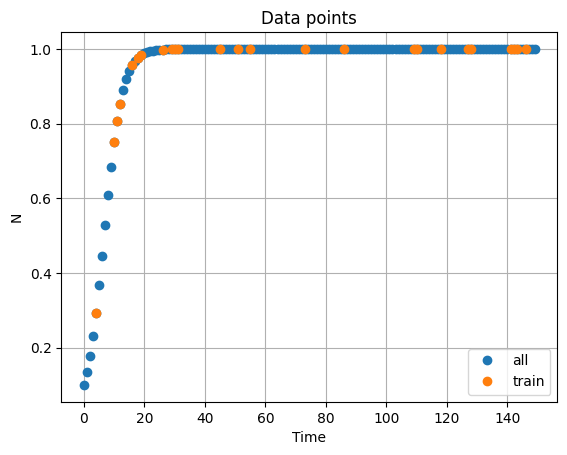

layers: [1, 10, 10, 1]
It: 0, Loss: 1.017e+00, pinn loss: 1.664e-07, data loss: 1.017e+00, r: 0.010, K: 1.000000
Loss: 4.513e-04, pinn loss: 2.980e-04, data loss: 1.533e-04, r: 0.252, K: 1.000000
Loss: 1.053e-05, pinn loss: 4.218e-06, data loss: 6.316e-06, r: 0.316, K: 1.000000
Loss: 1.034e-07, pinn loss: 2.000e-08, data loss: 8.342e-08, r: 0.330, K: 1.000000


 67%|██████▋   | 67/100 [03:27<02:11,  3.99s/it]

estimated alpha:  0.3298722803592682
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


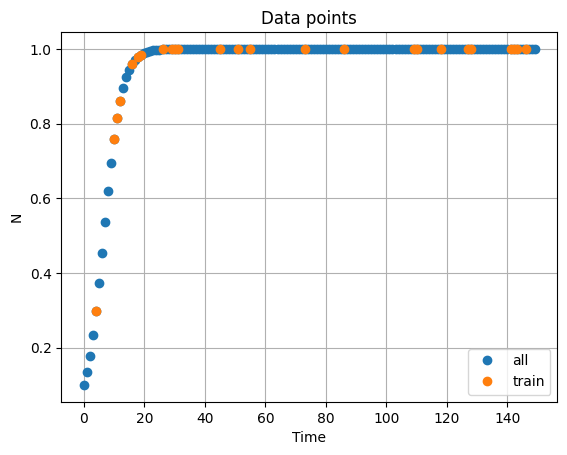

layers: [1, 10, 10, 1]
It: 0, Loss: 4.759e-01, pinn loss: 3.709e-06, data loss: 4.759e-01, r: 0.010, K: 1.000000
Loss: 1.213e-03, pinn loss: 4.560e-04, data loss: 7.567e-04, r: 0.018, K: 1.000000
Loss: 3.640e-04, pinn loss: 2.270e-04, data loss: 1.370e-04, r: 0.334, K: 1.000000


 68%|██████▊   | 68/100 [03:30<02:04,  3.90s/it]

estimated alpha:  0.33228063583374023
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


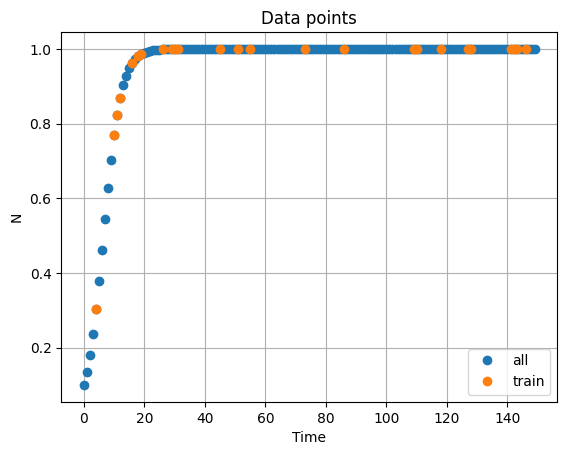

layers: [1, 10, 10, 1]
It: 0, Loss: 1.269e+00, pinn loss: 8.160e-06, data loss: 1.269e+00, r: 0.010, K: 1.000000
Loss: 9.876e-05, pinn loss: 6.251e-05, data loss: 3.625e-05, r: 0.415, K: 1.000000


 69%|██████▉   | 69/100 [03:34<01:57,  3.80s/it]

Loss: 5.986e-07, pinn loss: 3.959e-07, data loss: 2.028e-07, r: 0.342, K: 1.000000
estimated alpha:  0.3422397971153259
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


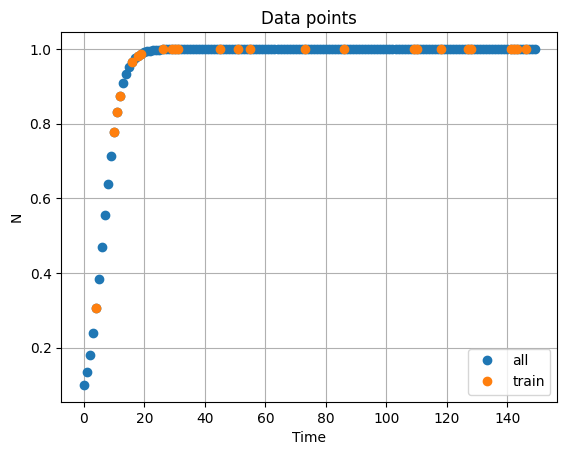

layers: [1, 10, 10, 1]
It: 0, Loss: 5.307e-01, pinn loss: 7.213e-06, data loss: 5.307e-01, r: 0.010, K: 1.000000
Loss: 4.827e-04, pinn loss: 2.938e-04, data loss: 1.889e-04, r: 0.315, K: 1.000000
Loss: 2.656e-05, pinn loss: 6.985e-06, data loss: 1.958e-05, r: 0.353, K: 1.000000
Loss: 6.578e-06, pinn loss: 5.380e-06, data loss: 1.198e-06, r: 0.355, K: 1.000000


 70%|███████   | 70/100 [03:39<02:01,  4.05s/it]

estimated alpha:  0.35459983348846436
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


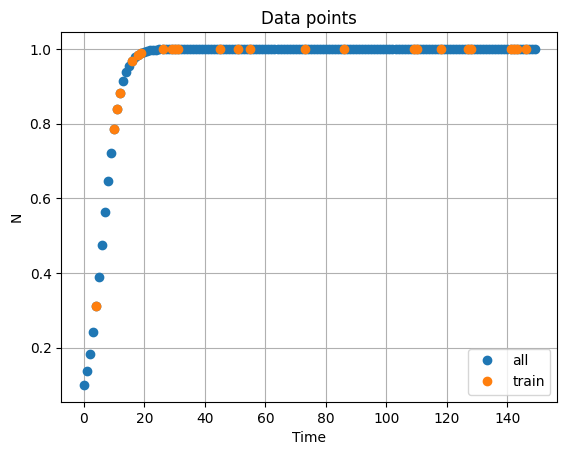

layers: [1, 10, 10, 1]
It: 0, Loss: 1.415e+00, pinn loss: 1.360e-05, data loss: 1.415e+00, r: 0.010, K: 1.000000
Loss: 6.429e-05, pinn loss: 4.699e-05, data loss: 1.731e-05, r: 0.386, K: 1.000000
Loss: 3.146e-06, pinn loss: 9.592e-07, data loss: 2.187e-06, r: 0.351, K: 1.000000
Loss: 3.188e-08, pinn loss: 1.351e-08, data loss: 1.836e-08, r: 0.350, K: 1.000000


 71%|███████   | 71/100 [03:43<02:05,  4.31s/it]

estimated alpha:  0.35026416182518005
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


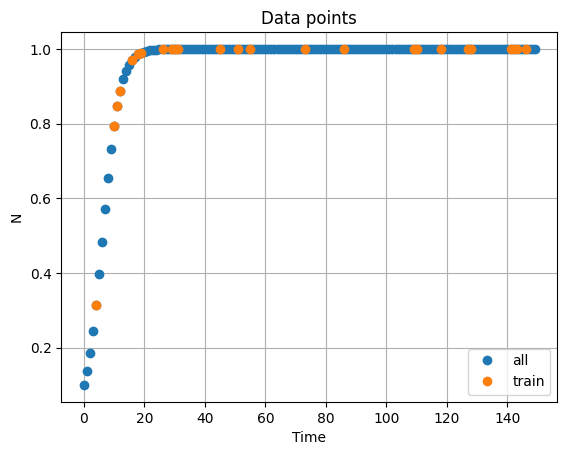

layers: [1, 10, 10, 1]
It: 0, Loss: 2.032e+00, pinn loss: 3.729e-05, data loss: 2.032e+00, r: 0.010, K: 1.000000
Loss: 2.071e-04, pinn loss: 1.253e-04, data loss: 8.187e-05, r: 0.365, K: 1.000000


 72%|███████▏  | 72/100 [03:47<01:54,  4.08s/it]

Loss: 7.244e-07, pinn loss: 2.717e-07, data loss: 4.527e-07, r: 0.354, K: 1.000000
estimated alpha:  0.35404300689697266
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


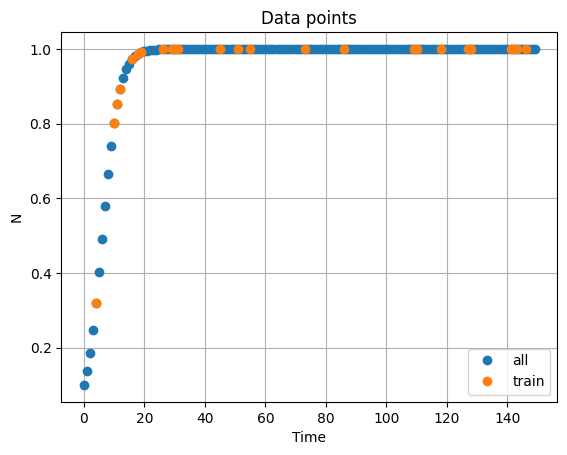

layers: [1, 10, 10, 1]
It: 0, Loss: 8.790e-01, pinn loss: 3.577e-07, data loss: 8.790e-01, r: 0.010, K: 1.000000
Loss: 3.392e-04, pinn loss: 1.848e-04, data loss: 1.544e-04, r: 0.331, K: 1.000000
Loss: 5.377e-06, pinn loss: 4.495e-06, data loss: 8.819e-07, r: 0.373, K: 1.000000
Loss: 9.636e-06, pinn loss: 2.135e-06, data loss: 7.501e-06, r: 0.364, K: 1.000000


 73%|███████▎  | 73/100 [03:52<01:53,  4.22s/it]

estimated alpha:  0.3615786135196686
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


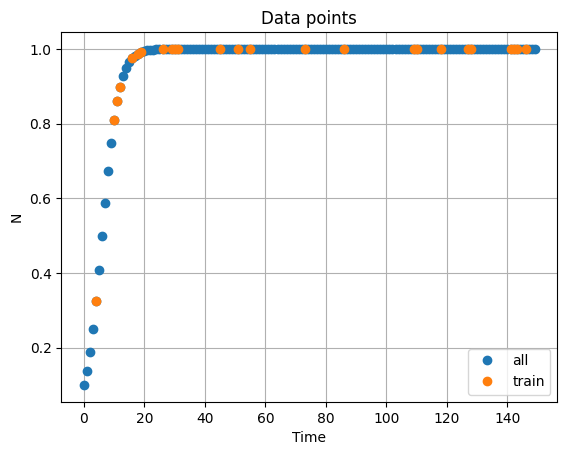

layers: [1, 10, 10, 1]
It: 0, Loss: 9.196e-01, pinn loss: 2.093e-07, data loss: 9.196e-01, r: 0.010, K: 1.000000
Loss: 5.384e-04, pinn loss: 2.785e-04, data loss: 2.600e-04, r: 0.341, K: 1.000000
Loss: 6.099e-06, pinn loss: 2.616e-06, data loss: 3.483e-06, r: 0.370, K: 1.000000


 74%|███████▍  | 74/100 [03:56<01:49,  4.22s/it]

estimated alpha:  0.3716675937175751
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


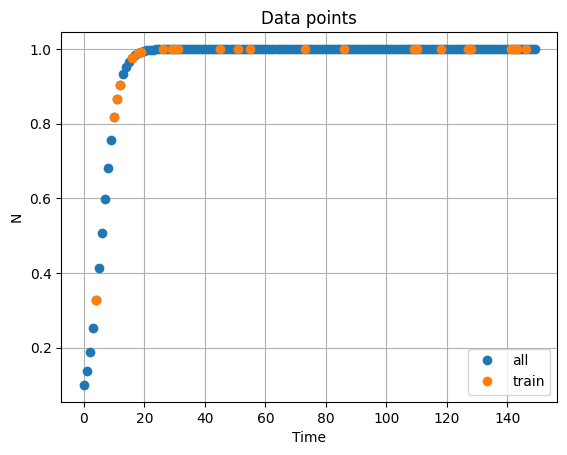

layers: [1, 10, 10, 1]
It: 0, Loss: 1.780e+00, pinn loss: 2.694e-05, data loss: 1.780e+00, r: 0.010, K: 1.000000
Loss: 1.117e-04, pinn loss: 6.333e-05, data loss: 4.838e-05, r: 0.388, K: 1.000000
Loss: 3.342e-06, pinn loss: 1.962e-06, data loss: 1.380e-06, r: 0.378, K: 1.000000
Loss: 4.049e-07, pinn loss: 9.301e-08, data loss: 3.119e-07, r: 0.371, K: 1.000000


 75%|███████▌  | 75/100 [04:01<01:52,  4.49s/it]

estimated alpha:  0.37016454339027405
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


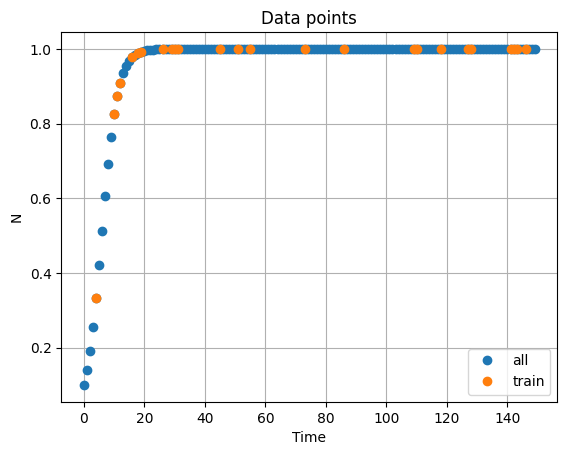

layers: [1, 10, 10, 1]
It: 0, Loss: 1.177e+00, pinn loss: 1.058e-06, data loss: 1.177e+00, r: 0.010, K: 1.000000
Loss: 6.242e-04, pinn loss: 3.271e-04, data loss: 2.970e-04, r: 0.370, K: 1.000000
Loss: 1.265e-06, pinn loss: 3.069e-07, data loss: 9.578e-07, r: 0.381, K: 1.000000


 76%|███████▌  | 76/100 [04:04<01:37,  4.07s/it]

estimated alpha:  0.3764118552207947
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


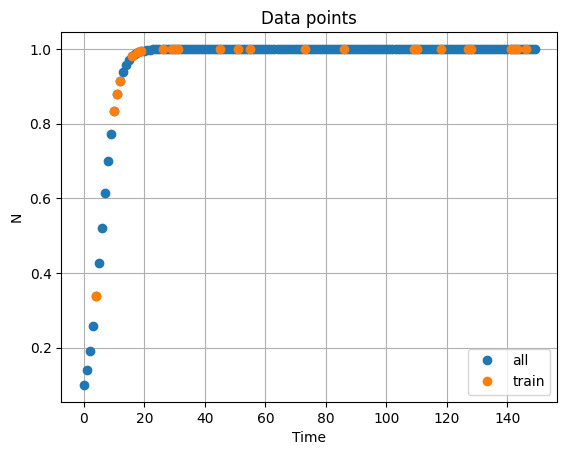

layers: [1, 10, 10, 1]
It: 0, Loss: 5.539e-01, pinn loss: 2.153e-06, data loss: 5.539e-01, r: 0.010, K: 1.000000
Loss: 8.860e-04, pinn loss: 4.434e-04, data loss: 4.426e-04, r: 0.164, K: 1.000000
Loss: 5.274e-04, pinn loss: 2.962e-04, data loss: 2.312e-04, r: 0.358, K: 1.000000
Loss: 1.688e-04, pinn loss: 8.423e-05, data loss: 8.461e-05, r: 0.398, K: 1.000000
Loss: 6.794e-06, pinn loss: 3.220e-06, data loss: 3.574e-06, r: 0.392, K: 1.000000


 77%|███████▋  | 77/100 [04:11<01:52,  4.87s/it]

estimated alpha:  0.3850310146808624
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


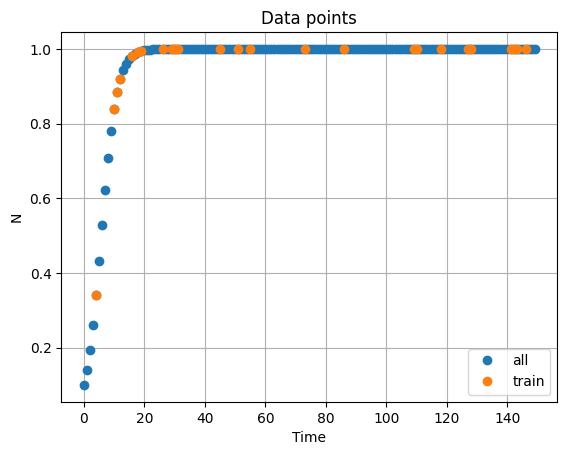

layers: [1, 10, 10, 1]
It: 0, Loss: 1.569e-01, pinn loss: 7.245e-06, data loss: 1.569e-01, r: 0.010, K: 1.000000
Loss: 4.494e-04, pinn loss: 2.344e-04, data loss: 2.151e-04, r: 0.376, K: 1.000000
Loss: 2.148e-04, pinn loss: 6.107e-05, data loss: 1.538e-04, r: 0.363, K: 1.000000
Loss: 2.499e-06, pinn loss: 1.745e-06, data loss: 7.538e-07, r: 0.391, K: 1.000000


 78%|███████▊  | 78/100 [04:15<01:45,  4.79s/it]

estimated alpha:  0.39365750551223755
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


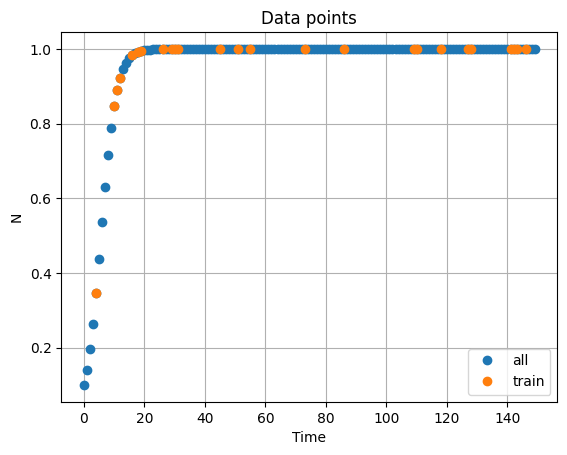

layers: [1, 10, 10, 1]
It: 0, Loss: 3.199e-01, pinn loss: 1.390e-06, data loss: 3.199e-01, r: 0.010, K: 1.000000
Loss: 6.509e-04, pinn loss: 3.111e-04, data loss: 3.398e-04, r: 0.309, K: 1.000000
Loss: 4.275e-05, pinn loss: 2.235e-05, data loss: 2.040e-05, r: 0.400, K: 1.000000
Loss: 4.047e-07, pinn loss: 3.187e-07, data loss: 8.600e-08, r: 0.387, K: 1.000000


 79%|███████▉  | 79/100 [04:21<01:43,  4.92s/it]

estimated alpha:  0.38896897435188293
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


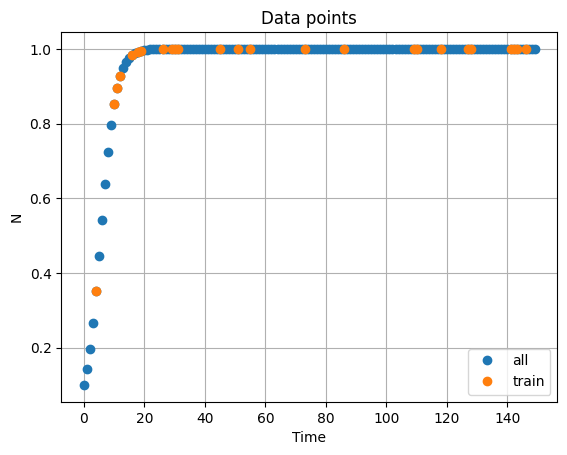

layers: [1, 10, 10, 1]
It: 0, Loss: 1.023e+00, pinn loss: 5.232e-07, data loss: 1.023e+00, r: 0.010, K: 1.000000
Loss: 2.246e-04, pinn loss: 1.129e-04, data loss: 1.116e-04, r: 0.407, K: 1.000000
Loss: 1.192e-06, pinn loss: 8.951e-07, data loss: 2.974e-07, r: 0.401, K: 1.000000


 80%|████████  | 80/100 [04:24<01:31,  4.55s/it]

estimated alpha:  0.3988214433193207
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


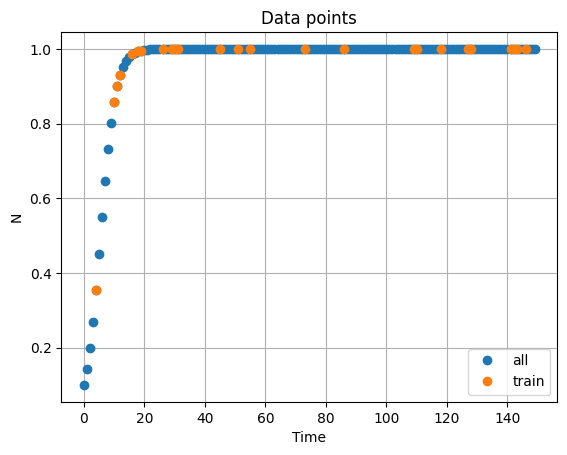

layers: [1, 10, 10, 1]
It: 0, Loss: 4.075e-01, pinn loss: 7.980e-06, data loss: 4.075e-01, r: 0.010, K: 1.000000
Loss: 6.221e-04, pinn loss: 3.023e-04, data loss: 3.198e-04, r: 0.379, K: 1.000000
Loss: 5.651e-05, pinn loss: 1.317e-05, data loss: 4.334e-05, r: 0.402, K: 1.000000
Loss: 5.894e-06, pinn loss: 4.847e-06, data loss: 1.048e-06, r: 0.415, K: 1.000000
Loss: 4.798e-06, pinn loss: 3.947e-06, data loss: 8.510e-07, r: 0.414, K: 1.000000
Loss: 3.947e-06, pinn loss: 3.322e-06, data loss: 6.250e-07, r: 0.413, K: 1.000000
Loss: 2.706e-06, pinn loss: 2.172e-06, data loss: 5.342e-07, r: 0.408, K: 1.000000


 81%|████████  | 81/100 [04:33<01:49,  5.76s/it]

estimated alpha:  0.4075096547603607
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


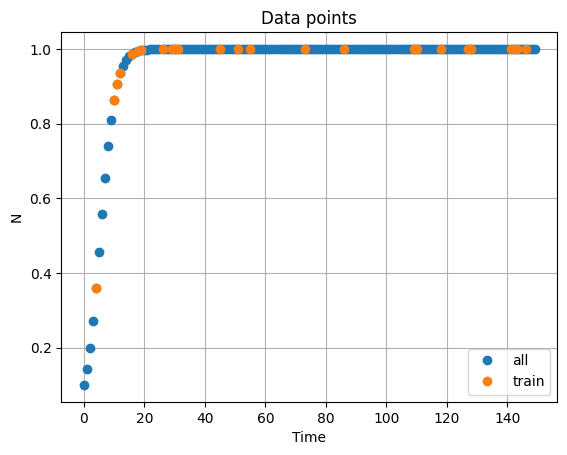

layers: [1, 10, 10, 1]
It: 0, Loss: 9.010e-01, pinn loss: 3.587e-07, data loss: 9.010e-01, r: 0.010, K: 1.000000
Loss: 2.302e-04, pinn loss: 1.570e-04, data loss: 7.322e-05, r: 0.318, K: 1.000000
Loss: 5.738e-06, pinn loss: 2.163e-06, data loss: 3.575e-06, r: 0.409, K: 1.000000


 82%|████████▏ | 82/100 [04:37<01:34,  5.25s/it]

estimated alpha:  0.41676780581474304
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


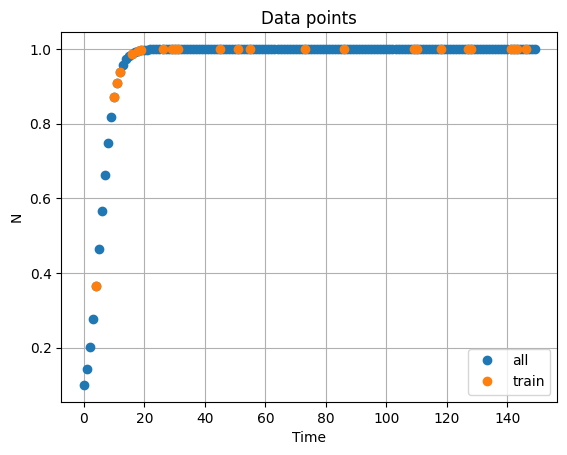

layers: [1, 10, 10, 1]
It: 0, Loss: 1.303e+00, pinn loss: 5.810e-06, data loss: 1.303e+00, r: 0.010, K: 1.000000
Loss: 5.402e-04, pinn loss: 2.653e-04, data loss: 2.749e-04, r: 0.497, K: 1.000000
Loss: 2.011e-04, pinn loss: 1.363e-04, data loss: 6.489e-05, r: 0.421, K: 1.000000
Loss: 6.935e-05, pinn loss: 3.649e-05, data loss: 3.286e-05, r: 0.412, K: 1.000000
Loss: 7.925e-06, pinn loss: 3.218e-06, data loss: 4.706e-06, r: 0.407, K: 1.000000
Loss: 2.996e-07, pinn loss: 8.869e-08, data loss: 2.109e-07, r: 0.410, K: 1.000000


 83%|████████▎ | 83/100 [04:45<01:41,  5.98s/it]

estimated alpha:  0.4096807539463043
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


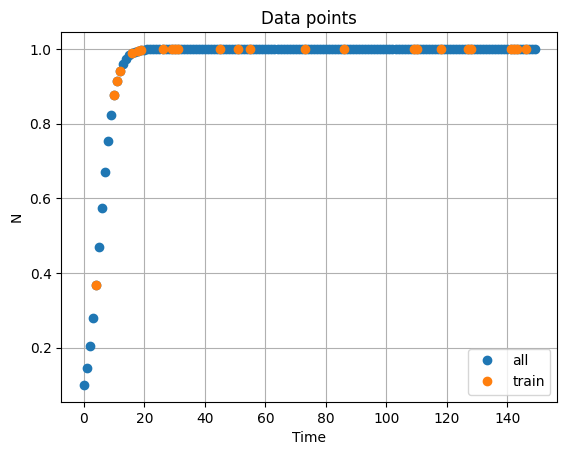

layers: [1, 10, 10, 1]
It: 0, Loss: 2.129e+00, pinn loss: 4.923e-05, data loss: 2.129e+00, r: 0.010, K: 1.000000
Loss: 8.036e-04, pinn loss: 3.139e-04, data loss: 4.897e-04, r: 0.349, K: 1.000000
Loss: 1.621e-05, pinn loss: 5.987e-06, data loss: 1.023e-05, r: 0.431, K: 1.000000
Loss: 2.357e-06, pinn loss: 1.915e-06, data loss: 4.416e-07, r: 0.424, K: 1.000000
Loss: 6.921e-07, pinn loss: 3.074e-07, data loss: 3.847e-07, r: 0.417, K: 1.000000
Loss: 1.634e-07, pinn loss: 9.626e-08, data loss: 6.719e-08, r: 0.416, K: 1.000000


 84%|████████▍ | 84/100 [04:51<01:40,  6.27s/it]

estimated alpha:  0.4159006178379059
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


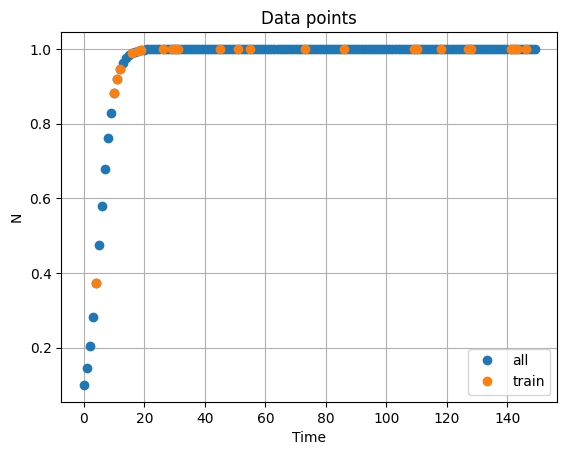

layers: [1, 10, 10, 1]
It: 0, Loss: 8.214e-01, pinn loss: 7.068e-07, data loss: 8.214e-01, r: 0.010, K: 1.000000
Loss: 3.704e-04, pinn loss: 1.203e-04, data loss: 2.500e-04, r: 0.410, K: 1.000000
Loss: 4.620e-06, pinn loss: 2.551e-06, data loss: 2.069e-06, r: 0.429, K: 1.000000


 85%|████████▌ | 85/100 [04:56<01:25,  5.69s/it]

estimated alpha:  0.4209171533584595
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


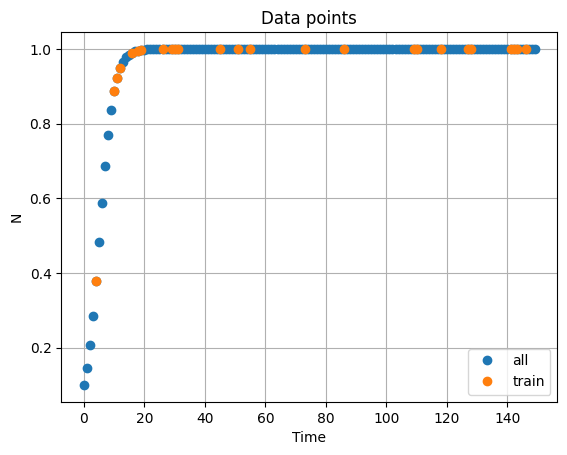

layers: [1, 10, 10, 1]
It: 0, Loss: 2.012e+00, pinn loss: 3.302e-05, data loss: 2.012e+00, r: 0.010, K: 1.000000
Loss: 8.228e-04, pinn loss: 3.511e-04, data loss: 4.716e-04, r: 0.322, K: 1.000000
Loss: 7.294e-06, pinn loss: 5.712e-06, data loss: 1.582e-06, r: 0.449, K: 1.000000


 86%|████████▌ | 86/100 [05:00<01:14,  5.32s/it]

Loss: 3.854e-08, pinn loss: 1.874e-08, data loss: 1.980e-08, r: 0.426, K: 1.000000
estimated alpha:  0.4258483052253723
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


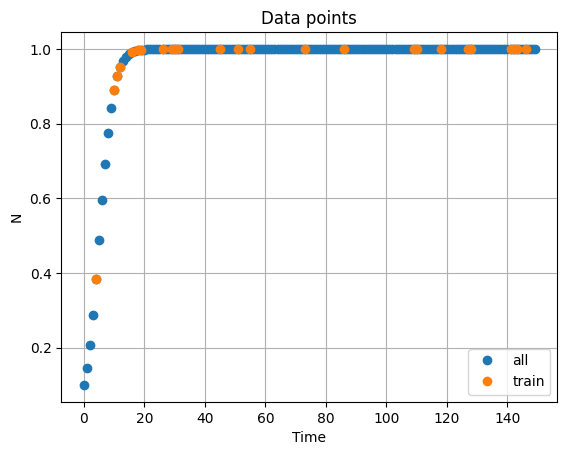

layers: [1, 10, 10, 1]
It: 0, Loss: 3.905e-01, pinn loss: 5.625e-07, data loss: 3.905e-01, r: 0.010, K: 1.000000
Loss: 8.105e-04, pinn loss: 3.346e-04, data loss: 4.759e-04, r: 0.452, K: 1.000000
Loss: 6.788e-04, pinn loss: 2.686e-04, data loss: 4.102e-04, r: 0.408, K: 1.000000
Loss: 5.308e-04, pinn loss: 2.605e-04, data loss: 2.703e-04, r: 0.412, K: 1.000000
Loss: 1.646e-04, pinn loss: 5.019e-05, data loss: 1.144e-04, r: 0.416, K: 1.000000


 87%|████████▋ | 87/100 [05:06<01:12,  5.55s/it]

estimated alpha:  0.4399115741252899
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


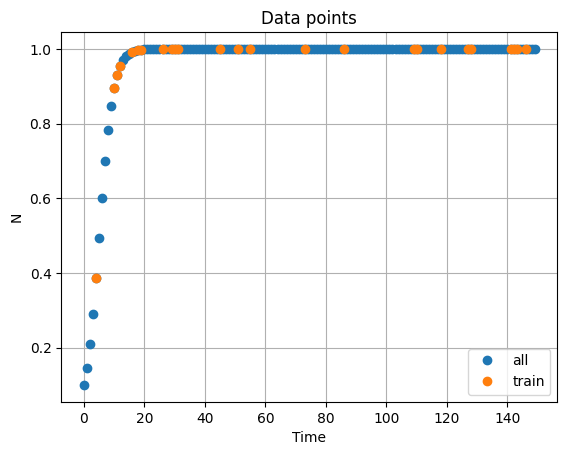

layers: [1, 10, 10, 1]
It: 0, Loss: 4.091e-01, pinn loss: 1.273e-06, data loss: 4.091e-01, r: 0.010, K: 1.000000
Loss: 8.284e-05, pinn loss: 1.917e-05, data loss: 6.366e-05, r: 0.422, K: 1.000000


 88%|████████▊ | 88/100 [05:10<00:57,  4.83s/it]

estimated alpha:  0.44739869236946106
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


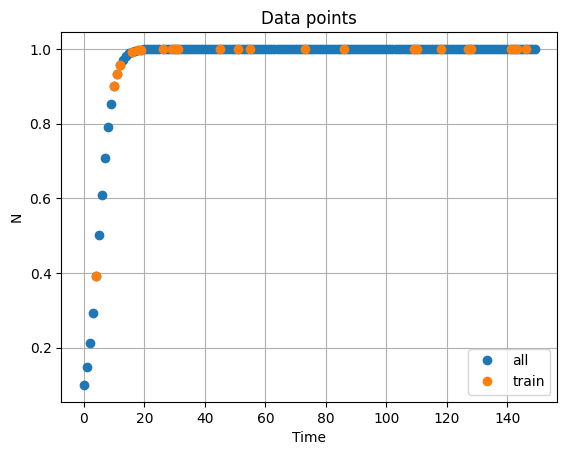

layers: [1, 10, 10, 1]
It: 0, Loss: 1.295e+00, pinn loss: 1.984e-06, data loss: 1.295e+00, r: 0.010, K: 1.000000
Loss: 4.329e-04, pinn loss: 2.412e-04, data loss: 1.917e-04, r: 0.532, K: 1.000000
Loss: 6.657e-06, pinn loss: 1.570e-06, data loss: 5.087e-06, r: 0.435, K: 1.000000


 89%|████████▉ | 89/100 [05:13<00:49,  4.47s/it]

estimated alpha:  0.4396032691001892
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


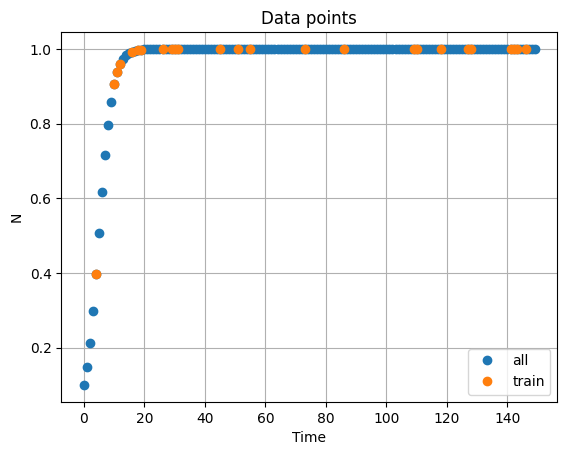

layers: [1, 10, 10, 1]
It: 0, Loss: 9.796e-01, pinn loss: 1.104e-06, data loss: 9.796e-01, r: 0.010, K: 1.000000


 90%|█████████ | 90/100 [05:15<00:37,  3.78s/it]

Loss: 1.670e-06, pinn loss: 8.945e-07, data loss: 7.756e-07, r: 0.446, K: 1.000000
estimated alpha:  0.4491425156593323
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


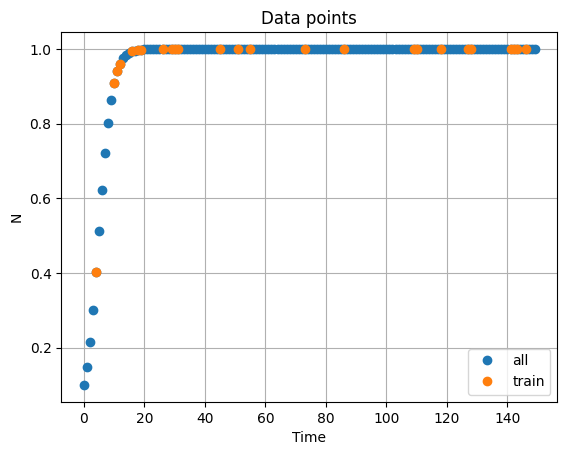

layers: [1, 10, 10, 1]
It: 0, Loss: 1.094e+00, pinn loss: 2.882e-06, data loss: 1.094e+00, r: 0.010, K: 1.000000
Loss: 1.281e-05, pinn loss: 6.092e-06, data loss: 6.719e-06, r: 0.417, K: 1.000000


 91%|█████████ | 91/100 [05:18<00:30,  3.37s/it]

estimated alpha:  0.46127331256866455
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


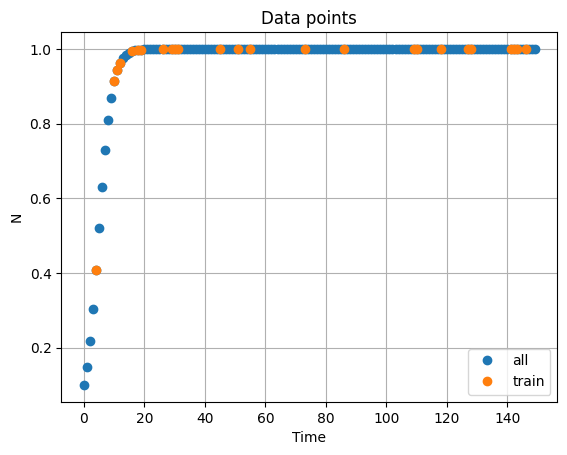

layers: [1, 10, 10, 1]
It: 0, Loss: 1.101e+00, pinn loss: 5.336e-07, data loss: 1.101e+00, r: 0.010, K: 1.000000
Loss: 5.294e-04, pinn loss: 2.595e-04, data loss: 2.699e-04, r: 0.534, K: 1.000000
Loss: 9.082e-06, pinn loss: 3.391e-06, data loss: 5.691e-06, r: 0.449, K: 1.000000
Loss: 2.322e-06, pinn loss: 1.380e-06, data loss: 9.418e-07, r: 0.462, K: 1.000000


 92%|█████████▏| 92/100 [05:23<00:32,  4.02s/it]

estimated alpha:  0.45592474937438965
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


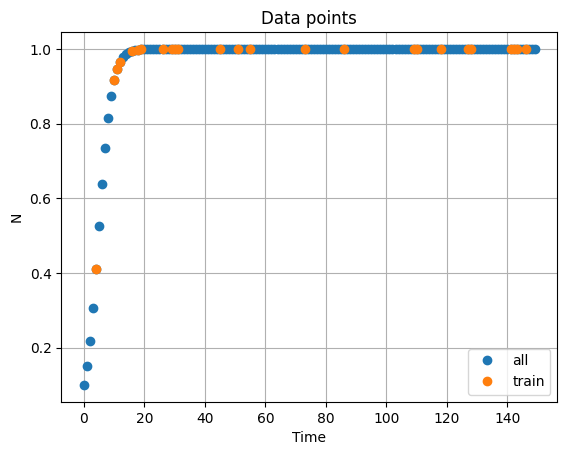

layers: [1, 10, 10, 1]
It: 0, Loss: 7.856e-01, pinn loss: 4.026e-06, data loss: 7.856e-01, r: 0.010, K: 1.000000
Loss: 2.430e-04, pinn loss: 1.138e-04, data loss: 1.292e-04, r: 0.555, K: 1.000000
Loss: 8.912e-07, pinn loss: 4.447e-07, data loss: 4.465e-07, r: 0.458, K: 1.000000
Loss: 7.656e-08, pinn loss: 2.844e-08, data loss: 4.812e-08, r: 0.459, K: 1.000000


 93%|█████████▎| 93/100 [05:28<00:29,  4.27s/it]

estimated alpha:  0.45932862162590027
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


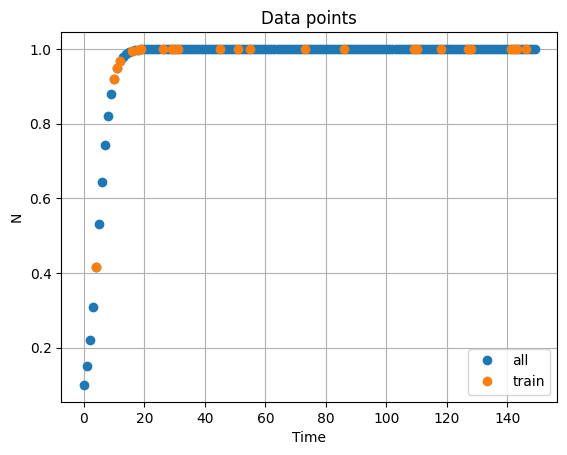

layers: [1, 10, 10, 1]
It: 0, Loss: 7.741e-01, pinn loss: 3.029e-07, data loss: 7.741e-01, r: 0.010, K: 1.000000
Loss: 7.233e-04, pinn loss: 2.105e-04, data loss: 5.129e-04, r: 0.372, K: 1.000000
Loss: 9.863e-05, pinn loss: 1.957e-05, data loss: 7.906e-05, r: 0.437, K: 1.000000


 94%|█████████▍| 94/100 [05:33<00:25,  4.31s/it]

estimated alpha:  0.4989335536956787
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


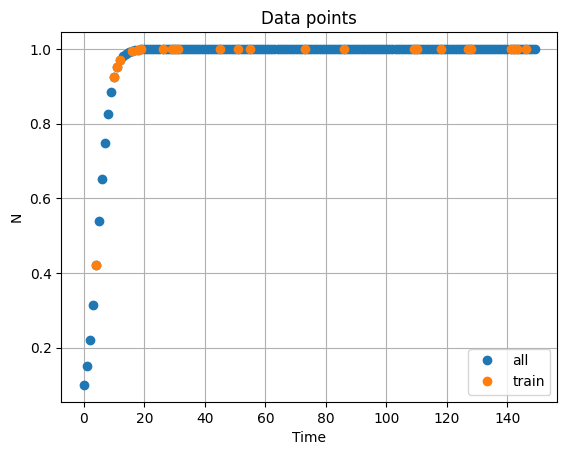

layers: [1, 10, 10, 1]
It: 0, Loss: 6.502e-01, pinn loss: 2.006e-06, data loss: 6.502e-01, r: 0.010, K: 1.000000
Loss: 6.811e-04, pinn loss: 2.639e-04, data loss: 4.173e-04, r: 0.420, K: 1.000000
Loss: 8.003e-05, pinn loss: 3.997e-05, data loss: 4.007e-05, r: 0.439, K: 1.000000
Loss: 3.496e-06, pinn loss: 1.351e-06, data loss: 2.145e-06, r: 0.457, K: 1.000000
Loss: 1.802e-06, pinn loss: 1.183e-06, data loss: 6.186e-07, r: 0.467, K: 1.000000
Loss: 1.371e-06, pinn loss: 9.154e-07, data loss: 4.557e-07, r: 0.470, K: 1.000000
Loss: 1.605e-07, pinn loss: 1.112e-07, data loss: 4.929e-08, r: 0.471, K: 1.000000


 95%|█████████▌| 95/100 [05:40<00:26,  5.38s/it]

estimated alpha:  0.46940767765045166
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


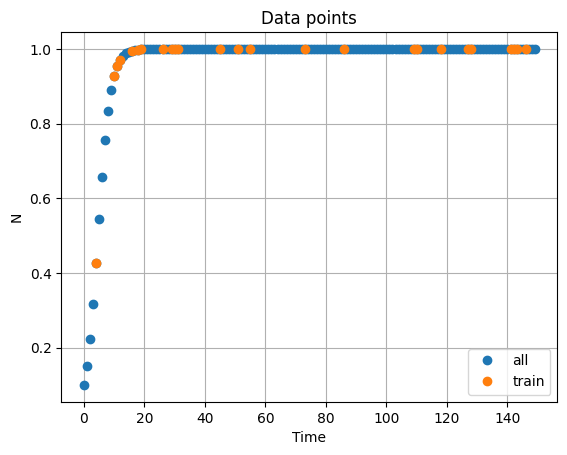

layers: [1, 10, 10, 1]
It: 0, Loss: 4.744e-01, pinn loss: 5.059e-06, data loss: 4.744e-01, r: 0.010, K: 1.000000
Loss: 2.449e-04, pinn loss: 1.101e-04, data loss: 1.348e-04, r: 0.524, K: 1.000000
Loss: 1.048e-06, pinn loss: 4.024e-07, data loss: 6.452e-07, r: 0.463, K: 1.000000


 96%|█████████▌| 96/100 [05:44<00:19,  4.82s/it]

estimated alpha:  0.46862444281578064
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


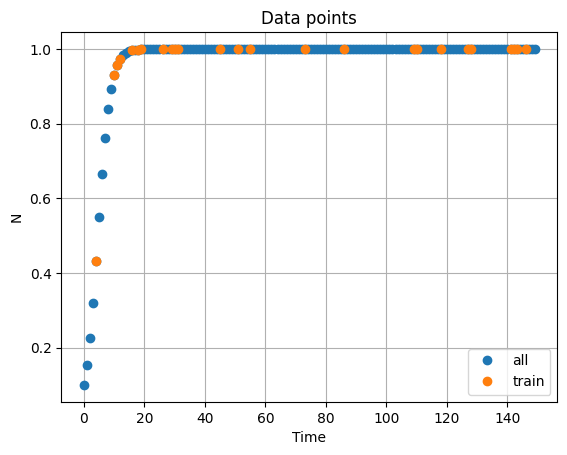

layers: [1, 10, 10, 1]
It: 0, Loss: 9.778e-01, pinn loss: 3.356e-07, data loss: 9.778e-01, r: 0.010, K: 1.000000
Loss: 7.097e-04, pinn loss: 3.703e-04, data loss: 3.393e-04, r: 0.287, K: 1.000000
Loss: 5.466e-05, pinn loss: 1.129e-05, data loss: 4.337e-05, r: 0.399, K: 1.000000
Loss: 1.059e-08, pinn loss: 6.159e-09, data loss: 4.429e-09, r: 0.479, K: 1.000000
Loss: 9.368e-09, pinn loss: 5.635e-09, data loss: 3.733e-09, r: 0.479, K: 1.000000


 97%|█████████▋| 97/100 [05:50<00:15,  5.09s/it]

estimated alpha:  0.47884032130241394
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


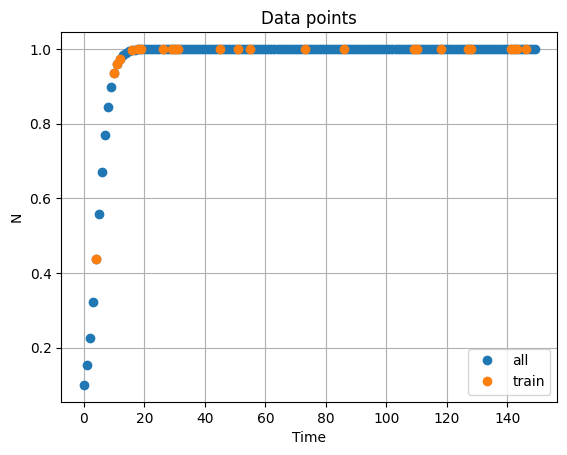

layers: [1, 10, 10, 1]
It: 0, Loss: 1.139e+00, pinn loss: 1.469e-06, data loss: 1.139e+00, r: 0.010, K: 1.000000
Loss: 4.588e-04, pinn loss: 2.645e-04, data loss: 1.943e-04, r: 0.479, K: 1.000000


 98%|█████████▊| 98/100 [05:53<00:08,  4.49s/it]

Loss: 2.527e-06, pinn loss: 1.542e-06, data loss: 9.852e-07, r: 0.481, K: 1.000000
estimated alpha:  0.48119595646858215
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


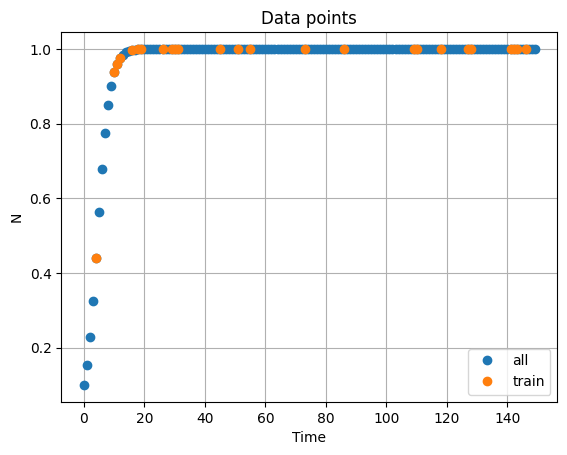

layers: [1, 10, 10, 1]
It: 0, Loss: 1.612e+00, pinn loss: 1.904e-05, data loss: 1.612e+00, r: 0.010, K: 1.000000
Loss: 2.206e-04, pinn loss: 9.047e-05, data loss: 1.301e-04, r: 0.328, K: 1.000000
Loss: 2.659e-06, pinn loss: 1.533e-06, data loss: 1.127e-06, r: 0.493, K: 1.000000


 99%|█████████▉| 99/100 [05:57<00:04,  4.54s/it]

Loss: 5.341e-07, pinn loss: 2.736e-07, data loss: 2.605e-07, r: 0.487, K: 1.000000
estimated alpha:  0.4871838390827179
num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


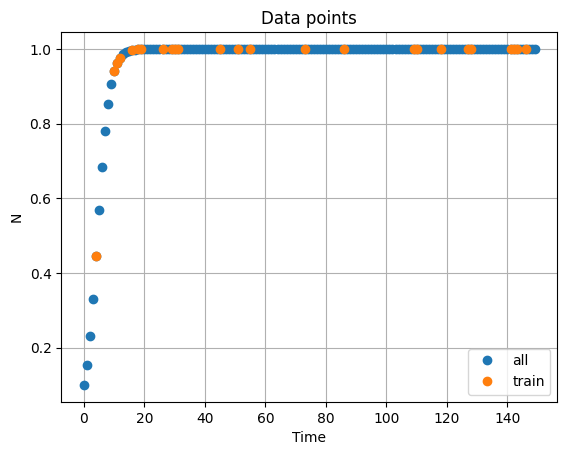

layers: [1, 10, 10, 1]
It: 0, Loss: 6.462e-01, pinn loss: 1.434e-06, data loss: 6.462e-01, r: 0.010, K: 1.000000
Loss: 6.176e-04, pinn loss: 2.156e-04, data loss: 4.020e-04, r: 0.318, K: 1.000000
Loss: 1.930e-03, pinn loss: 2.379e-04, data loss: 1.692e-03, r: 0.426, K: 1.000000
Loss: 2.056e-05, pinn loss: 6.586e-06, data loss: 1.398e-05, r: 0.417, K: 1.000000
Loss: 2.352e-06, pinn loss: 1.695e-06, data loss: 6.566e-07, r: 0.483, K: 1.000000
Loss: 2.200e-06, pinn loss: 1.565e-06, data loss: 6.353e-07, r: 0.482, K: 1.000000
Loss: 9.628e-07, pinn loss: 7.134e-07, data loss: 2.494e-07, r: 0.484, K: 1.000000
Loss: 1.654e-07, pinn loss: 1.144e-07, data loss: 5.101e-08, r: 0.489, K: 1.000000


100%|██████████| 100/100 [06:07<00:00,  3.68s/it]

estimated alpha:  0.49262112379074097


<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 2. Setup Training
print("Step 2. Set Up Training")

"""## Configurations"""

#layers = [1, 20, 20, 20, 20, 20, 20, 20, 20, 1]
layers = [1, 10, 10, 1] # MTR
t_colloc = np.expand_dims(np.arange(0, 150.0, 0.001),axis=1)

"""## Training on Non-noisy Data"""

'''
adam_epochs = 1000
polish_adam_epochs = 2000
bfgs_epochs = 2000
'''
adam_epochs = 100 # MTR
polish_adam_epochs = 200 # MTR
bfgs_epochs = 200 # MTR

#true_alphas = np.arange(0.0, 0.5, 0.5/100.0) # can also test on a smaller set [0.01,0.02,0.05,0.1,0.3,0.5] which will run faster
true_alphas = np.arange(0.0, 0.5, 0.5/100.0) # MTR

print("true alphas: ", true_alphas)

inferred_alphas = []

all_PINNs = [] # MTR
all_data = [] # MTR
all_inferred_alphas = [] # MTR
all_true_alphas = [] # MTR
for idx, alpha in enumerate(tqdm(true_alphas)):
  # train a PINN for each alpha
  data = generate_data(noise=0.0,alpha=alpha,id=idx)
  model = PhysicsInformedNN(t_colloc, layers, data["t_train"], data["N_train"])
  model.train(adam_epochs, bfgs_epochs, polish_adam_epochs)
  print("estimated alpha: ",model.r.item())
  inferred_alphas.append(model.r.item())
  # MTR
  all_PINNs.append(model) # MTR
  all_data.append(data) # MTR
  all_inferred_alphas.append(model.r.item())
  all_true_alphas.append(alpha)

In [ ]:
print("true alphas: ",true_alphas)
print("inferred alphas",inferred_alphas)

#np.savetxt('inferred_alphas.csv', inferred_alphas, delimiter=',',header='inferred alphas')
np.savetxt('inferred_alphas_MTR_noisy.csv', inferred_alphas, delimiter=',',header='inferred alphas')#MTR

true alphas:  [0.    0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045 0.05  0.055
 0.06  0.065 0.07  0.075 0.08  0.085 0.09  0.095 0.1   0.105 0.11  0.115
 0.12  0.125 0.13  0.135 0.14  0.145 0.15  0.155 0.16  0.165 0.17  0.175
 0.18  0.185 0.19  0.195 0.2   0.205 0.21  0.215 0.22  0.225 0.23  0.235
 0.24  0.245 0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295
 0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4   0.405 0.41  0.415
 0.42  0.425 0.43  0.435 0.44  0.445 0.45  0.455 0.46  0.465 0.47  0.475
 0.48  0.485 0.49  0.495]
inferred alphas [-0.0003672706079669297, 0.004416214767843485, 0.010973374359309673, 0.014529571868479252, 0.02040211111307144, 0.022219620645046234, 0.02805882878601551, 0.03582923486828804, 0.04172363132238388, 0.0436004176735878, 0.04237409308552742, 0.048265229910612106, 0.04738934338092804, 0.05394328758120537, 0.053371138870716095, 0.07680212706327438, 0.0752518773078

num calibration: (100,),(100, 1)
num train: (25,),(25, 1)
num test: (25,),(25, 1)


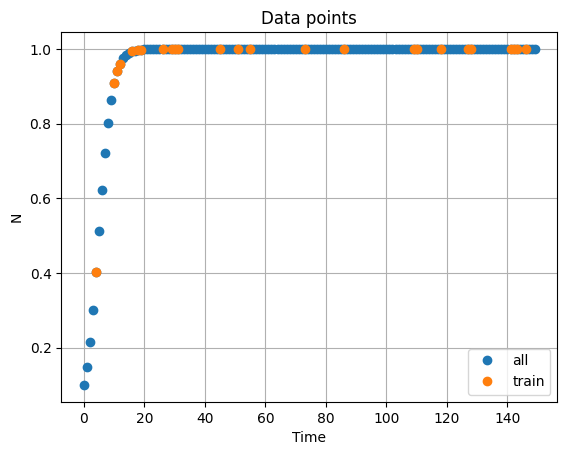

<Figure size 640x480 with 0 Axes>

In [ ]:
tmp = generate_data(noise=0.0,alpha=alpha,id=idx)

In [ ]:
tmp.keys()

dict_keys(['id', 'alpha', 'noise', 't', 't_train', 't_test', 't_cal', 'N', 'N_train', 'N_test', 'N_cal'])

len(true_alphas) =  100
len(inferred_alphas) =  100


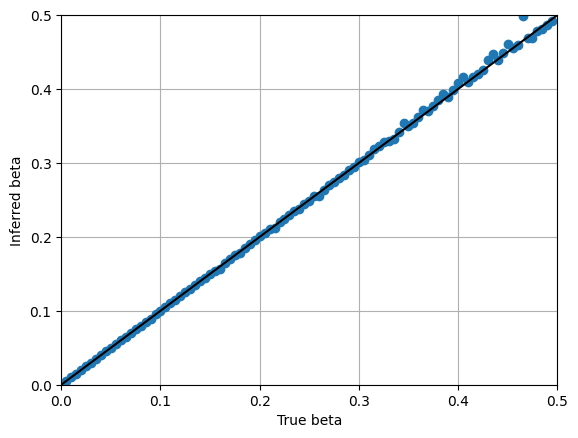

In [ ]:
print("len(true_alphas) = ",len(true_alphas))
print("len(inferred_alphas) = ",len(inferred_alphas))

plt.plot(true_alphas,inferred_alphas,'o')
plt.xlabel("True beta")
plt.ylabel("Inferred beta")
plt.ylim([0,0.5])
plt.xlim([0,0.5])
plt.gca().axline((0, 0), slope=1,c='k')
# plt.title("True alpha vs predicted")
plt.grid()

In [ ]:
# MTR
'''
# evaluations
u_pred= model.predict(model.t_colloc) # predict on collocation time-points
u_pred_calibration = model.predict(t_cal) # predict on calibration points
# print(u_pred)

plt.title("Trajectories")
plt.xlabel('Time')
plt.ylabel("N")
# plt.plot(t_train, N_train, 'o',label='train data')
plt.plot(t_cal,N_cal,'o',label='True calibration points')
plt.plot(t_cal, u_pred_calibration, 'o',label='calibration prediction')
# plt.plot(t_test, N_test, 'o',label='test data')
# plt.plot(model.t_colloc.detach().cpu().numpy(), u_pred[:, 0],'-', label='PINN approximation', color='r')
plt.savefig('trajectories')
plt.legend()
plt.show()
'''

'\n# evaluations\nu_pred= model.predict(model.t_colloc) # predict on collocation time-points\nu_pred_calibration = model.predict(t_cal) # predict on calibration points\n# print(u_pred)\n\nplt.title("Trajectories")\nplt.xlabel(\'Time\')\nplt.ylabel("N")\n# plt.plot(t_train, N_train, \'o\',label=\'train data\')\nplt.plot(t_cal,N_cal,\'o\',label=\'True calibration points\')\nplt.plot(t_cal, u_pred_calibration, \'o\',label=\'calibration prediction\')\n# plt.plot(t_test, N_test, \'o\',label=\'test data\')\n# plt.plot(model.t_colloc.detach().cpu().numpy(), u_pred[:, 0],\'-\', label=\'PINN approximation\', color=\'r\')\nplt.savefig(\'trajectories\')\nplt.legend()\nplt.show()\n'

In [ ]:
'''
class Conformalizer():
  def __init__(self,
               pre_trained_model,
               non_conformity_func,
               delta,
               calib_data):

    # Initialize the conformalizer with required parameters
    self.point_predictor = pre_trained_model
    self.non_conformity_func = non_conformity_func
    self.n_calib = calib_data['X'].shape[0]
    self.delta = delta
    #self.X_calib, self.y_calib = calib_data['X'], calib_data['y']
    self._calibrate(calib_data['X'], calib_data['y'])


  def _calculate_quantile(self, scores_calib, delta):
    # Calculate the quantile value based on delta and non-conformity scores
    self.which_quantile = np.ceil((self.delta)*(self.n_calib + 1))/self.n_calib
    return np.quantile(scores_calib, self.which_quantile, method='lower')


  def _calibrate(self, X_calib, y_calib):
    # Calibrate the conformalizer to calculate q_hat
    y_calib_pred = self.point_predictor.predict(X_calib)
    scores_calib = self.non_conformity_func(y_calib_pred, y_calib)
    self.q_hat = self._calculate_quantile(scores_calib, self.delta)


  def predict(self, X):
    # Returns the predicted interval
    y_pred = self.point_predictor.predict(X)
    y_lower, y_upper = y_pred - self.q_hat, y_pred + self.q_hat
    return y_lower, y_pred, y_upper
'''

"\nclass Conformalizer():\n  def __init__(self,\n               pre_trained_model,\n               non_conformity_func,\n               delta,\n               calib_data):\n\n    # Initialize the conformalizer with required parameters\n    self.point_predictor = pre_trained_model\n    self.non_conformity_func = non_conformity_func\n    self.n_calib = calib_data['X'].shape[0]\n    self.delta = delta\n    #self.X_calib, self.y_calib = calib_data['X'], calib_data['y']\n    self._calibrate(calib_data['X'], calib_data['y'])\n\n\n  def _calculate_quantile(self, scores_calib, delta):\n    # Calculate the quantile value based on delta and non-conformity scores\n    self.which_quantile = np.ceil((self.delta)*(self.n_calib + 1))/self.n_calib\n    return np.quantile(scores_calib, self.which_quantile, method='lower')\n\n\n  def _calibrate(self, X_calib, y_calib):\n    # Calibrate the conformalizer to calculate q_hat\n    y_calib_pred = self.point_predictor.predict(X_calib)\n    scores_calib = self

In [ ]:
def non_conformity_func(y, y_hat):
  return np.abs(y - y_hat)

In [ ]:
id_of_PINN_selected_for_conformalization = 9
all_data[id_of_PINN_selected_for_conformalization].keys()

dict_keys(['id', 'alpha', 'noise', 't', 't_train', 't_test', 't_cal', 'N', 'N_train', 'N_test', 'N_cal'])

0.045083872973918915
0.045


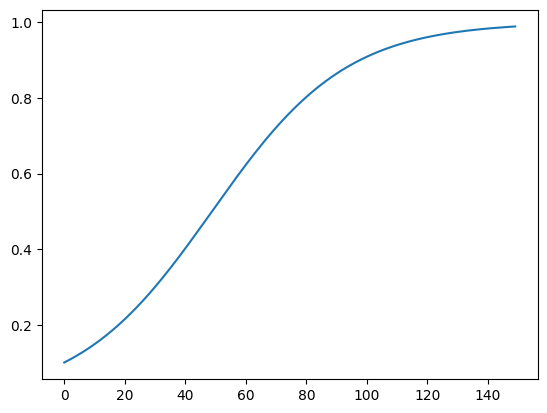

In [ ]:
print(all_inferred_alphas[id_of_PINN_selected_for_conformalization])
print(all_true_alphas[id_of_PINN_selected_for_conformalization])
plt.plot(all_data[id_of_PINN_selected_for_conformalization]['t'], all_data[id_of_PINN_selected_for_conformalization]['N'])

In [ ]:
all_true_alphas

[0.0,
 0.05,
 0.1,
 0.15000000000000002,
 0.2,
 0.25,
 0.30000000000000004,
 0.35000000000000003,
 0.4,
 0.45]

In [ ]:
'''
fresh_points_for_conformalizer_X = t_cal
fresh_points_for_conformalizer_y = N_cal
'''
fresh_points_for_conformalizer_X = np.array(all_true_alphas)
fresh_points_for_conformalizer_y = np.array(all_inferred_alphas) # model predictions
# true values should be all_true_alphas


In [ ]:
len(all_true_alphas)

10

In [ ]:
alpha = 0.2 # miscoverage
sig_level_delta = 1 - alpha
calib_data, valid_data = {}, {}
n_calib = 80
#n_valid = fresh_points_for_conformalizer_X.shape[0] - n_calib
n_valid = 20

lower_bound, upper_bound, exact_coverage = sig_level_delta, (sig_level_delta + 1/(n_calib+1)), (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# To see how the relations for upper bound and the exact coverage are derived, see the following video:
# Uncertainty Quantification (4A): Implementing Split Conformal - Relation for Prediction Intervals


empirical_coverages_for_all_trials = []
#num_trials = 10000
num_trials = 10000

for trial_num in range(num_trials):

  calib_data['X'], valid_data['X'], calib_data['y'], valid_data['y'] = train_test_split(
      fresh_points_for_conformalizer_X,
      fresh_points_for_conformalizer_y,
      test_size=n_valid
      )
  # print(calib_data['y'])
  # print(valid_data['y'])

  #conformalized_model = Conformalizer(model, non_conformity_func, sig_level_delta, calib_data)
  #y_lower, y_pred, y_upper = conformalized_model.predict(valid_data['X'])


  scores_calib = non_conformity_func(calib_data['X'], calib_data['y'])
  which_quantile = np.ceil((sig_level_delta)*(n_calib + 1))/n_calib

  q_hat = np.quantile(scores_calib, which_quantile, method='lower')

  #id_of_PINN = np.random.randint(0, len(all_true_alphas)) # randomly select a PINN
  # id_of_PINN = id_of_PINN_selected_for_conformalization
  # y_lower, y_pred, y_upper = all_inferred_alphas[id_of_PINN] - q_hat, all_inferred_alphas[id_of_PINN], all_inferred_alphas[id_of_PINN] + q_hat

  y_lower, y_pred, y_upper = valid_data['y'] - q_hat, valid_data['y'], valid_data['y'] + q_hat


  # valid_data['X'] also serves as the true value of alpha to which to compare
  fraction_within_bounds = np.mean((valid_data['X'] >= y_lower) & (valid_data['X'] <= y_upper))
  empirical_coverage = fraction_within_bounds
  empirical_coverages_for_all_trials.append(empirical_coverage)


In [ ]:
def running_average(arr):
  cumsum = np.cumsum(arr)
  indices = np.arange(1, len(arr) + 1)
  running_avg = cumsum / indices
  return running_avg

In [ ]:
running_averages = running_average(empirical_coverages_for_all_trials)

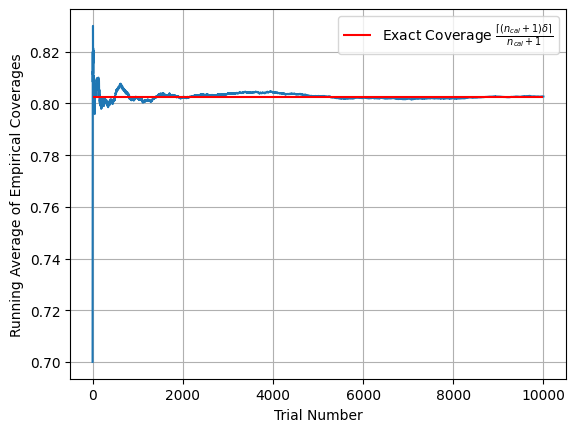

In [ ]:
plt.plot(running_averages)
plt.grid()
# plt.hlines(lower_bound, 0, num_trials, label=r'Lower Bound = 1 - $\alpha$')
# plt.hlines(upper_bound, 0, num_trials, label=r'Upper Bound = 1 - $\alpha$ + $\frac{1}{n_{cal}+1}$')
plt.hlines(exact_coverage, 0, num_trials, label=r'Exact Coverage $\frac{\lceil (n_{cal}+1)\delta \rceil}{n_{cal}+1}$', color='r')
# (np.ceil((n_calib+1)*sig_level_delta))/(n_calib+1)
# \frac{\lceil (n+1) \cdot \text{sig\_level} \rceil}{n+1}
plt.xlabel('Trial Number')
plt.ylabel('Running Average of Empirical Coverages')
plt.legend()
#plt.ylim(0.899, 0.903)

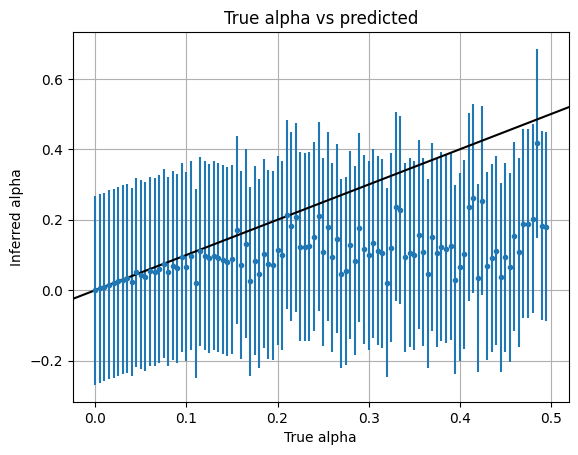

In [ ]:
plt.errorbar(true_alphas,inferred_alphas,yerr=q_hat,fmt='.')
plt.xlabel("True alpha")
plt.ylabel("Inferred alpha")
plt.gca().axline((0, 0), slope=1,c='k')
plt.title("True alpha vs predicted")
plt.grid()